In [1]:
# 사용할 패키지를 import합니다
import sys
print('python', sys.version)

import numpy as np
print('numpy', np.__version__)

import pandas as pd
print('pandas', pd.__version__)

import matplotlib as mpl
print('matplotlib', mpl.__version__)

import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic") # 한글표시 (window)
plt.rc("axes", unicode_minus=False) # x,y축 (-)부호 표시

# 레티나 디스플레이로 폰트가 선명하게 표시되도록 합니다.
from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

import seaborn as sns
print('seaborn', sns.__version__)

# 결과 확인을 용이하게 하기 위한 코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# 모든 컬럼이 표시되도록 max_columns 의 수를 지정합니다.
pd.options.display.max_columns = 39

# 경고 메시지는 출력되지 않게 합니다.
import warnings
warnings.filterwarnings("ignore")

python 3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]
numpy 1.21.5
pandas 1.4.2
matplotlib 3.5.1


C:\Users\kimha\AppData\Local\Temp\ipykernel_24940\3930909792.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats("retina")


seaborn 0.11.2


In [ ]:
data = pd.read_excel("경진대회용데이터.xlsx")

# 데이터 전처리

In [3]:
df = data.iloc[:,:76]
df = df.dropna(axis=1)
df

,id,시도명,시군구명,읍면동명,행정리명,조사가구번호,q1_1,q1_2,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q3,q4,q5,gagu_n,q7,...,q27_1,q27_2,q27_3,q27_4,q27_5,q27_6,q27_7,q27_8,q27_9,q27_10,q28,q29_1_1,q29_1_2,q30,q31_1,q31_2,q31_3,q31_4,q31_5
0,1,인천광역시,강화군,선원면,냉정리,1,고추,2-3,2,1,2,2,2,2,1,4,1,1,1,...,2,5,4,5,4,5,5,5,5,5,3,6,6,2,2,2,2,2,2
1,2,인천광역시,강화군,선원면,냉정리,2,마늘,2-13,2,1,2,2,2,2,3,4,2,1,1,...,4,4,4,4,4,4,4,4,4,4,2,2,2,2,1,1,1,1,1
2,3,인천광역시,강화군,선원면,냉정리,3,소,5-6,2,2,2,2,1,2,3,4,1,1,1,...,3,4,4,4,4,4,4,4,4,4,2,6,6,2,1,2,1,2,2
3,4,인천광역시,강화군,선원면,냉정리,4,고구마,2-2,2,1,2,2,2,2,3,1,4,1,3,...,4,4,4,4,4,4,4,4,4,4,3,6,6,2,1,2,1,2,2
4,5,인천광역시,강화군,선원면,냉정리,5,고추,2-3,2,1,2,2,2,2,2,2,2,1,3,...,4,4,4,4,4,4,4,4,4,4,2,6,6,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17765,17766,제주특별자치도,서귀포시,예래동,예래동03,7,밀감,2-36,2,1,2,2,2,2,2,4,1,1,1,...,4,5,5,5,4,5,5,5,5,5,2,3,1,3,2,2,2,2,2
17766,17767,제주특별자치도,서귀포시,예래동,예래동03,8,밀감,2-36,2,1,2,2,2,2,3,4,3,1,1,...,1,4,5,4,5,4,5,5,5,5,2,6,6,3,2,2,2,2,2
17767,17768,제주특별자치도,서귀포시,예래동,예래동03,9,밀감,2-36,2,1,2,2,2,2,4,4,2,1,1,...,4,4,5,5,4,5,5,5,5,5,2,6,6,3,2,2,2,2,2
17768,17769,제주특별자치도,서귀포시,예래동,예래동03,9,밀감,2-36,2,1,2,2,2,2,4,4,2,2,1,...,4,4,5,5,4,5,5,5,5,5,1,6,6,3,2,2,2,2,2


In [4]:
df[df['q26']==5]['q1_1'].unique()
df[df['q1_1']=='살구']['q26'].value_counts()

array(['고추', '벼', '수박', '꿀벌', '매실', '장미', '콩', '복숭아', '들깨', '포도', '배',
       '옥수수', '토마토', '사과', '참외', '닭', '배추', '오이', '호박', '밤', '수수', '참깨',
       '감자', '더덕', '조경수', '고구마', '단감', '마늘', '체리', '팥', '감', '소', '한우',
       '방울토마토', '버섯', '소나무', '양파', '젖소', '커피', '자두', '무화과', '샤인머스캣', '딸기',
       '대추', '살구', '블루베리', '오미자', '담배', '산딸기', '구아바', '취나물', '귤', '브로콜리',
       '밀감', '키위', '천혜향', '레드향', '한라봉', '감귤'], dtype=object)

5    4
Name: q26, dtype: int64

### 손상은 1, 비손상은 0인 target 열 만들기

In [5]:
d = []
for i in data["q32_1"]:
    if i == 1:
        d.append(1)
    else:
        d.append(0)
        
df["target"] = d

In [6]:
df.head()

,id,시도명,시군구명,읍면동명,행정리명,조사가구번호,q1_1,q1_2,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q3,q4,q5,gagu_n,q7,...,q27_2,q27_3,q27_4,q27_5,q27_6,q27_7,q27_8,q27_9,q27_10,q28,q29_1_1,q29_1_2,q30,q31_1,q31_2,q31_3,q31_4,q31_5,target
0,1,인천광역시,강화군,선원면,냉정리,1,고추,2-3,2,1,2,2,2,2,1,4,1,1,1,...,5,4,5,4,5,5,5,5,5,3,6,6,2,2,2,2,2,2,0
1,2,인천광역시,강화군,선원면,냉정리,2,마늘,2-13,2,1,2,2,2,2,3,4,2,1,1,...,4,4,4,4,4,4,4,4,4,2,2,2,2,1,1,1,1,1,0
2,3,인천광역시,강화군,선원면,냉정리,3,소,5-6,2,2,2,2,1,2,3,4,1,1,1,...,4,4,4,4,4,4,4,4,4,2,6,6,2,1,2,1,2,2,0
3,4,인천광역시,강화군,선원면,냉정리,4,고구마,2-2,2,1,2,2,2,2,3,1,4,1,3,...,4,4,4,4,4,4,4,4,4,3,6,6,2,1,2,1,2,2,0
4,5,인천광역시,강화군,선원면,냉정리,5,고추,2-3,2,1,2,2,2,2,2,2,2,1,3,...,4,4,4,4,4,4,4,4,4,2,6,6,2,2,2,2,2,2,0


## 등간척도로 문항 값 변경

### 4점척도

In [7]:
df4 = df[['q3','q4','q12','q13','q20','q22']]
df4

,q3,q4,q12,q13,q20,q22
0,1,4,4,1,1,2
1,3,4,3,1,2,2
2,3,4,3,1,2,2
3,3,1,3,1,2,2
4,2,2,3,1,1,1
...,...,...,...,...,...,...
17765,2,4,3,3,2,2
17766,3,4,4,1,4,2
17767,4,4,4,1,2,1
17768,4,4,4,1,2,1


### 5점 척도

In [8]:
q26 = []
for i in df['q26']:
    if i == 1:
        q26.append(5)
    elif i==2:
        q26.append(4)
    elif i==4:
        q26.append(2)
    elif i==5:
        q26.append(1)
    else:
        q26.append(3)

df["q26"] = q26

In [9]:
df5 = df[['q23', 'q24', 'q26']]
df5

,q23,q24,q26
0,1,1,5
1,1,1,5
2,1,1,5
3,4,1,5
4,4,1,5
...,...,...,...
17765,1,1,5
17766,1,1,5
17767,1,1,4
17768,1,1,4


## 수치 데이터 

In [10]:
dfn = df[['q10','q11', 'target']]
dfn

,q10,q11,target
0,64,40,0
1,75,27,0
2,69,49,0
3,62,1,0
4,75,10,0
...,...,...,...
17765,75,40,0
17766,60,35,0
17767,56,30,0
17768,59,30,0


## 예(1)/아니오(0)로 변경

In [11]:
df2 = df[['시도명','시군구명','읍면동명','q2_1_1','q2_2_1','q2_3_1','q2_4_1','q2_5_1','q2_6_1','q7','q9','q14','q17','q31_1','q31_2','q31_3','q31_4','q31_5']]

In [ ]:
df27 = df.filter(regex='q27_')

In [11]:
df27 = df.filter(regex='q27_')

for i in df27.index:
    for j in df27.columns:
        if df27.loc[i,j] == 4 or df27.loc[i,j] == 5:
            df27.loc[i,j] = 0
        else:
            df27.loc[i,j] = 1

In [12]:
li = ['q2_1_1','q2_2_1','q2_3_1','q2_4_1','q2_5_1','q2_6_1']
for i in li:
    q2 = []
    for j in df2[i]:
        if j == 1:
            q2.append(1)
        else :
            q2.append(0)
    df2[i] = q2

In [13]:
q7 = []
for i in df2['q7']:
    if i == 1:
        q7.append(1)
    elif i == 2 :
        q7.append(1)
    else:
        q7.append(0)
df2['q7'] = q7

In [14]:
q9 = []
for i in df2['q9']:
    if i == 1:
        q9.append('남성')
    else:
        q9.append('여성')
df2['q9'] = q9

In [15]:
df2 = pd.get_dummies(columns = ['q9'], data = df2) # 더미변수 생성

In [16]:
q14 = []
for i in df2['q14']:
    if i == 1:
        q14.append(1)
    else:
        q14.append(0)
df2['q14'] = q14

In [17]:
q17 = []
for i in df2['q17']:
    if i == 1:
        q17.append(0)
    elif i == 2 :
        q17.append(0)
    else :
        q17.append(1)
df2['q17'] = q17

In [18]:
li = ['q31_1','q31_2','q31_3','q31_4','q31_5']

for i in li:
    q31 = []
    for j in df2[i]:
        if j == 2:
            q31.append(1)
        else :
            q31.append(0)
    df2[i] = q31

In [19]:
df2 = pd.concat([df2, df27], axis = 1)
df2.head()

,시도명,시군구명,읍면동명,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q7,q14,q17,q31_1,q31_2,q31_3,q31_4,q31_5,q9_남성,q9_여성,q27_1,q27_2,q27_3,q27_4,q27_5,q27_6,q27_7,q27_8,q27_9,q27_10
0,인천광역시,강화군,선원면,0,1,0,0,0,0,1,0,1,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0
1,인천광역시,강화군,선원면,0,1,0,0,0,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,인천광역시,강화군,선원면,0,0,0,0,1,0,1,1,1,0,1,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0
3,인천광역시,강화군,선원면,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0
4,인천광역시,강화군,선원면,0,1,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0


## 데이터 병합

In [16]:
df_all =  pd.concat([df2, df4, df5, dfn], axis = 1)
df_all.head()

,시도명,시군구명,읍면동명,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q7,q9,q14,q17,q31_1,q31_2,q31_3,q31_4,q31_5,q3,q4,q12,q13,q20,q22,q23,q24,q26,q10,q11,target
0,인천광역시,강화군,선원면,2,1,2,2,2,2,1,2,2,3,2,2,2,2,2,1,4,4,1,1,2,1,1,5,64,40,0
1,인천광역시,강화군,선원면,2,1,2,2,2,2,1,1,1,3,1,1,1,1,1,3,4,3,1,2,2,1,1,5,75,27,0
2,인천광역시,강화군,선원면,2,2,2,2,1,2,1,1,1,3,1,2,1,2,2,3,4,3,1,2,2,1,1,5,69,49,0
3,인천광역시,강화군,선원면,2,1,2,2,2,2,3,1,2,1,1,2,1,2,2,3,1,3,1,2,2,4,1,5,62,1,0
4,인천광역시,강화군,선원면,2,1,2,2,2,2,3,1,2,3,2,2,2,2,2,2,2,3,1,1,1,4,1,5,75,10,0


# 특성 중요도 

In [13]:
pip install mglearn

  Created wheel for mglearn: filename=mglearn-0.1.9-py2.py3-none-any.whl size=582637 sha256=fd20c9cc1edc1b9c6026872718f2c03bdff5e25c5d81a218f90e98e1d5176777
  Stored in directory: c:\users\qpflw\appdata\local\pip\cache\wheels\df\30\8a\1e2c8f144c9d411b0688f628d496d2db8f61b6d14bcedaa1df
Successfully built mglearn
Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpt
import matplotlib.colors as mcl
import mglearn
import numpy as np

RandomForestClassifier(random_state=0)

훈련 세트 정확도 : 1.000
테스트 세트 정확도 : 0.973
특성 중요도 : 
[0.02936157 0.02586466 0.0141287  0.01497663 0.01151567 0.00021103
 0.02297758 0.02036297 0.01664913 0.03553173 0.03127332 0.02763632
 0.03208782 0.02031378 0.02087948 0.05109676 0.04734409 0.04273294
 0.08562674 0.04260904 0.03528163 0.04341919 0.03015803 0.04144833
 0.14227768 0.11423519]


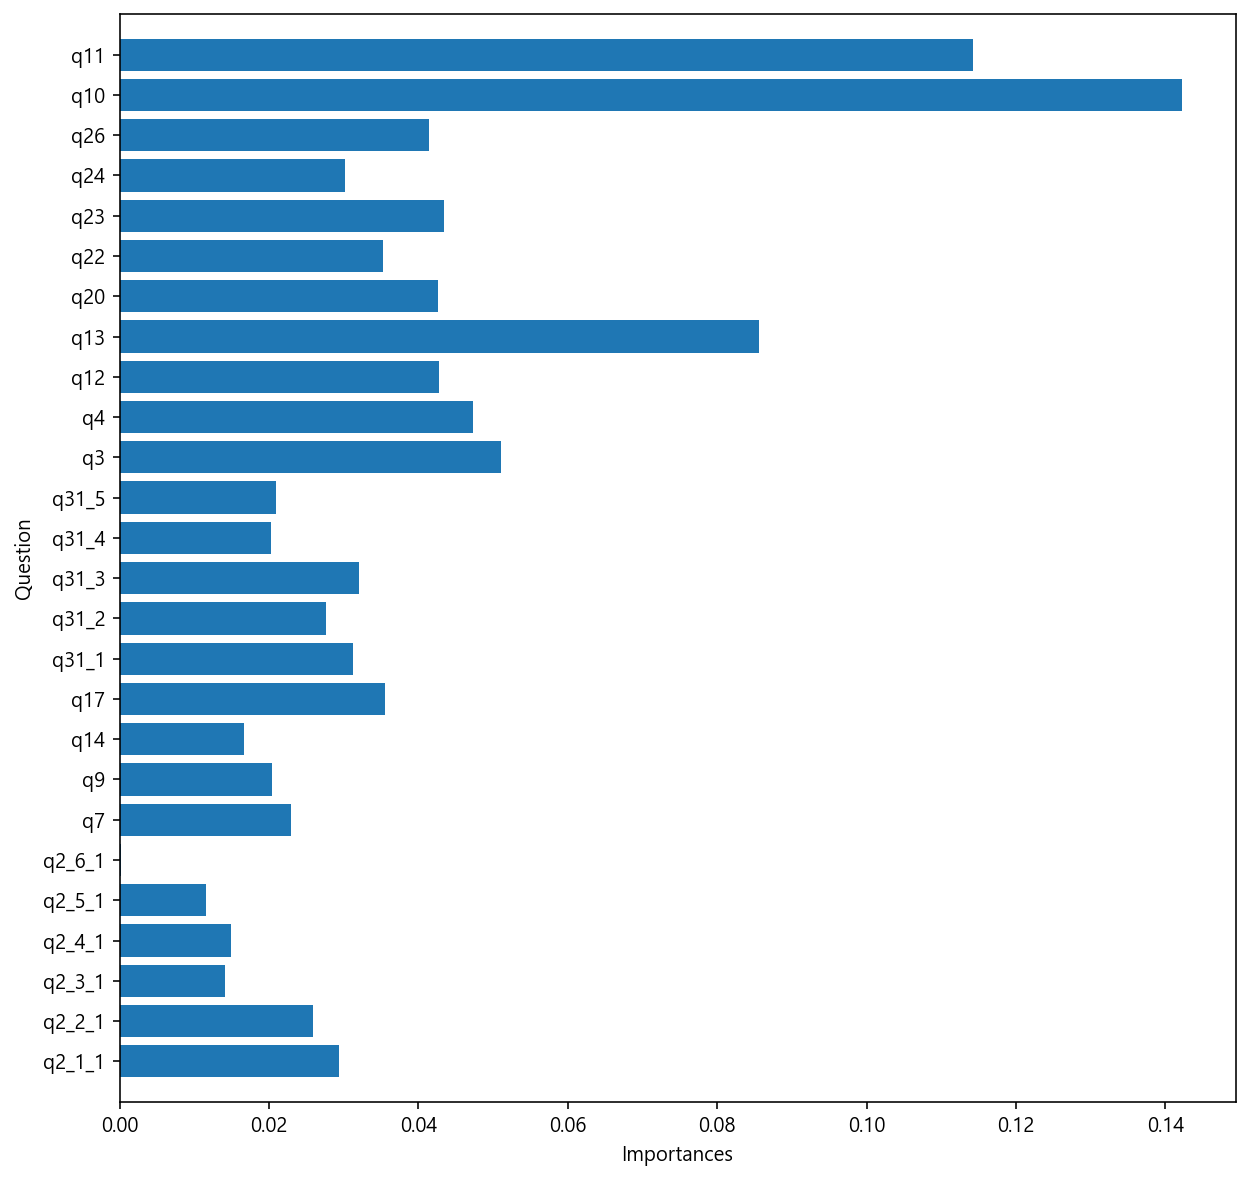

In [17]:
d_data = df_all.iloc[:,3:-1]
d_target = df_all["target"]

x_train, x_test, y_train, y_test = train_test_split(d_data, d_target, random_state=0)

forest = RandomForestClassifier(n_estimators=100,random_state=0)

forest.fit(x_train,y_train)

print("훈련 세트 정확도 : {:.3f}".format(forest.score(x_train,y_train)))

print("테스트 세트 정확도 : {:.3f}".format(forest.score(x_test,y_test)))

print("특성 중요도 : \n{}".format(forest.feature_importances_))



def plot_feature_importances(model):

    n_features = d_data.shape[1]
    
    plt.figure(figsize = (10, 10))

    plt.barh(range(n_features), model.feature_importances_, align='center')

    plt.yticks(np.arange(n_features), d_data)

    plt.xlabel("Importances")

    plt.ylabel("Question")

    plt.ylim(-1, n_features)

plt.show()

plot_feature_importances(forest)

# 특성 중요도별 손상자 비율 시각화

## 상위 5개 시각화

### 연령

In [24]:
d_age = df_all[['q10', 'target']]

li10 = []
for i in d_age['q10']:
    if i < 50:
        li10.append('20-40대')
    elif 50 <= i < 60:
        li10.append('50대')
    elif 60 <= i < 70:
        li10.append('60대')
    elif 70 <= i < 80:
        li10.append('70대')
    else:
        li10.append('80대 이상')
        
d_age["연령"] = li10

d_age.head(5)

,q10,target,연령
0,64,0,60대
1,75,0,70대
2,69,0,60대
3,62,0,60대
4,75,0,70대


In [25]:
sample_age = pd.DataFrame(columns=['연령','target'])
for i in d_age['연령'].unique():
    temp_age = d_age.query('연령==@i').sample(n=5000, replace = True)
    sample_age = pd.concat([sample_age,temp_age]) 
    
sample_age = sample_age.reset_index(drop=True)
sample_age.head(5)

s_age = pd.pivot_table(sample_age, index = ['연령'], values = 'target', aggfunc = 'sum')
s_age

,연령,target,q10
0,60대,0,61.0
1,60대,0,60.0
2,60대,0,66.0
3,60대,0,60.0
4,60대,0,67.0


,target
연령,
20-40대,70
50대,119
60대,145
70대,145
80대 이상,121


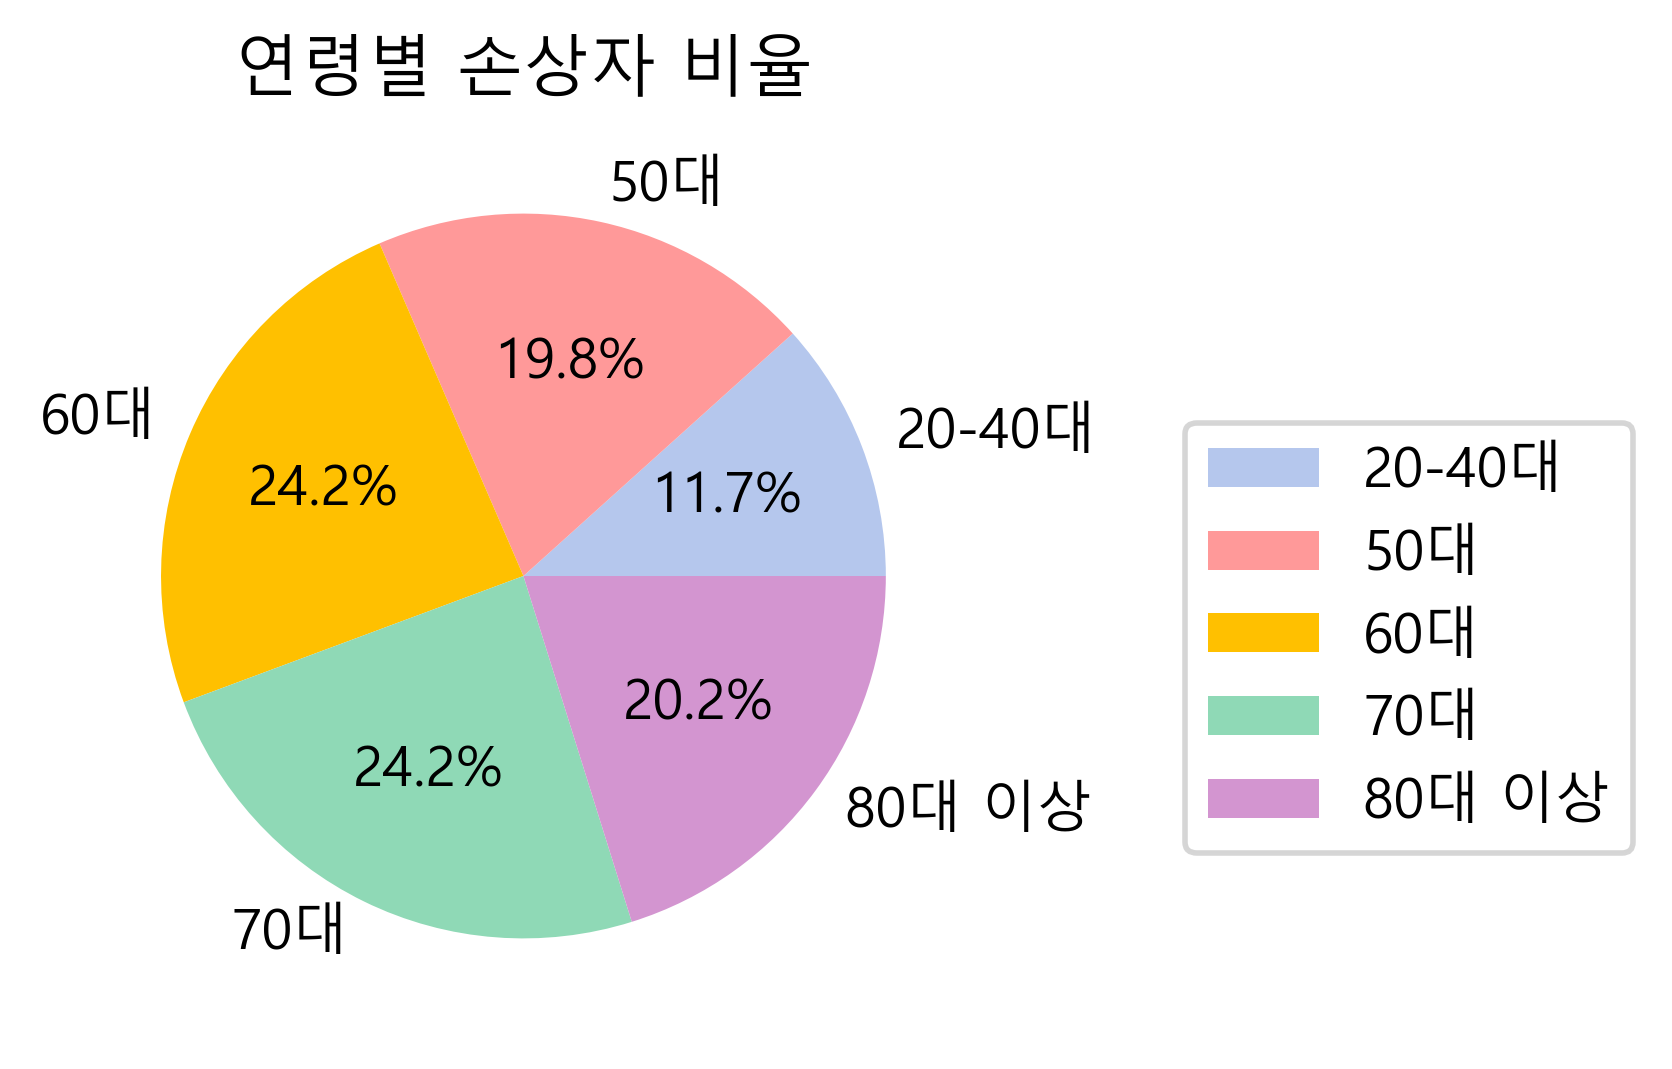

In [26]:
fig = plt.figure(figsize = (3,3), dpi = 200)
ax = fig.subplots()

colors = ['#b5c7ed', '#ff9999', '#ffc000', '#8fd9b6', '#d395d0']

_ = ax.pie(s_age['target'], labels = s_age.index, colors = colors, autopct = '%1.1f%%')
_ = ax.set_title('연령별 손상자 비율')
_ = ax.legend(labels = s_age.index, bbox_to_anchor = (1.2, 0.7) )

### 종사기간

In [27]:
d_year = df_all[['q11', 'target']]

q1 = []
for i in d_year['q11']:
    if i >= 60:
        q1.append('60년 이상')
    elif 50 <= i < 60:
        q1.append('약 50년')
    elif 40 <= i < 50:
        q1.append('약 40년')
    elif 30 <= i < 40:
        q1.append('약 30년')
    elif 10 <= i < 30:
        q1.append('약 10~30년')
    else:
        q1.append('10년 이하')
    
d_year["종사기간"] = q1

In [28]:
sample_year = pd.DataFrame(columns=['종사기간','target'])
for i in d_year['종사기간'].unique():
    temp_year = d_year.query('종사기간==@i').sample(n=5000, replace = True)
    sample_year = pd.concat([sample_year,temp_year]) 
    
sample_year = sample_year.reset_index(drop=True)
sample_year.head(5)

s_year = pd.pivot_table(sample_year, index = ['종사기간'], values = 'target', aggfunc = 'sum')
s_year

,종사기간,target,q11
0,약 40년,0,47.0
1,약 40년,0,40.0
2,약 40년,0,40.0
3,약 40년,0,45.0
4,약 40년,0,44.0


,target
종사기간,
10년 이하,150
60년 이상,147
약 10~30년,121
약 30년,170
약 40년,114
약 50년,145


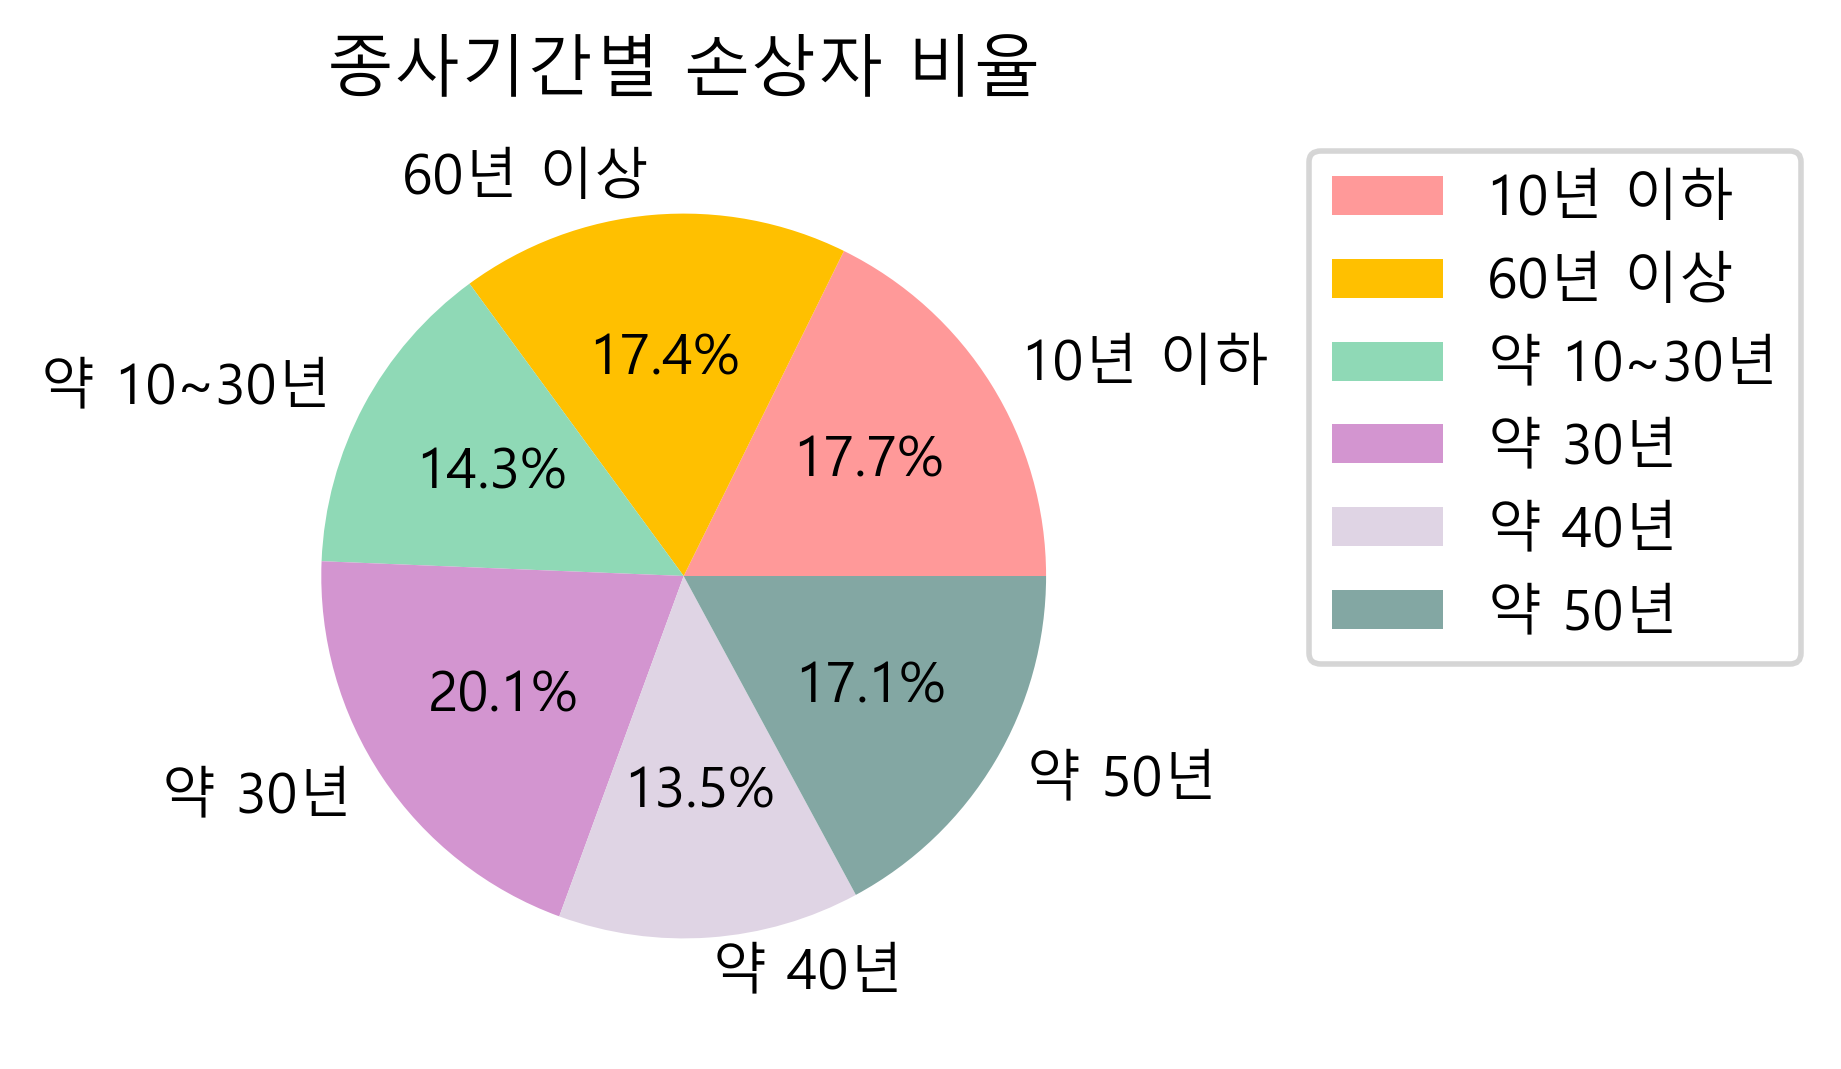

In [29]:
fig = plt.figure(figsize = (3,3), dpi = 200)
ax = fig.subplots()

colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0','#dfd4e4', '#83a7a3', '#acb890']

_ = ax.pie(s_year['target'], labels = s_year.index, colors = colors, autopct = '%1.1f%%')
_ = ax.set_title('종사기간별 손상자 비율')
_ = ax.legend(labels = s_year.index, bbox_to_anchor = (1.16, 1.0))

### 신체, 정신적 어려움

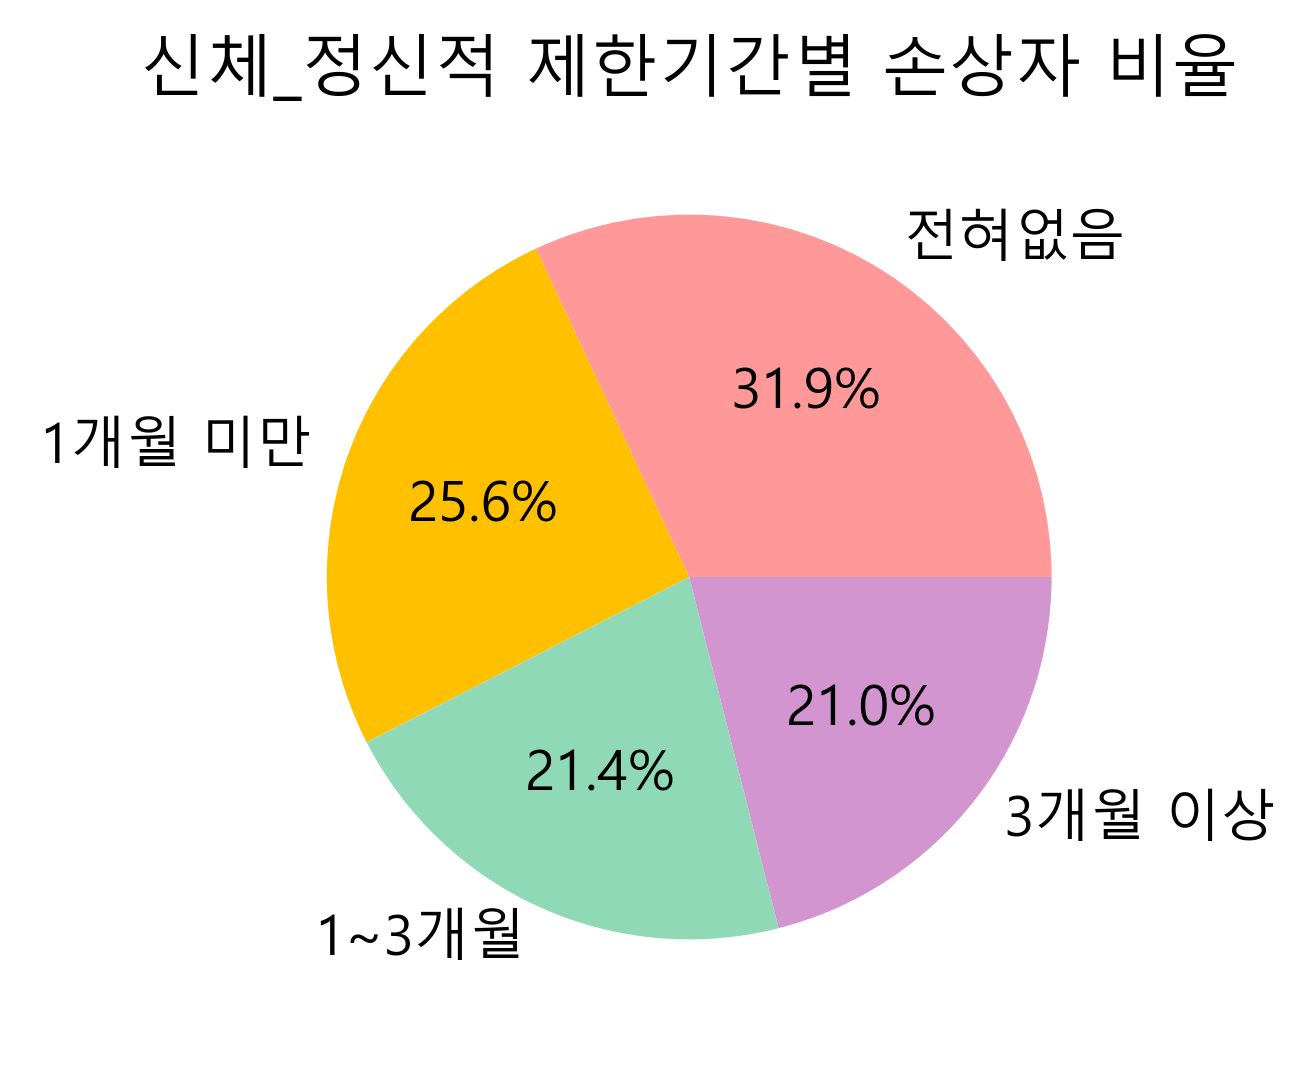

In [30]:
df13 = df.loc[df['target'] == 1]['q13']
dfli = df13.value_counts()
dfli = pd.DataFrame(dfli)
dlist = ['전혀없음', '1개월 미만', '1~3개월', '3개월 이상']
dfli["기간"] = dlist
dfli = dfli.set_index(dfli["기간"])
dfli = dfli.drop(columns=['기간'])

fig = plt.figure(figsize=(3,3), dpi=200)
ax1 = fig.subplots()
colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0']
_ = ax1.pie(dfli['q13'], labels=dfli.index, autopct='%.1f%%', colors=colors)
_ = ax1.set_title("신체_정신적 제한기간별 손상자 비율")
# _ = ax1.legend(dfli.index, bbox_to_anchor=(1.0, 0.9))

### 총소득

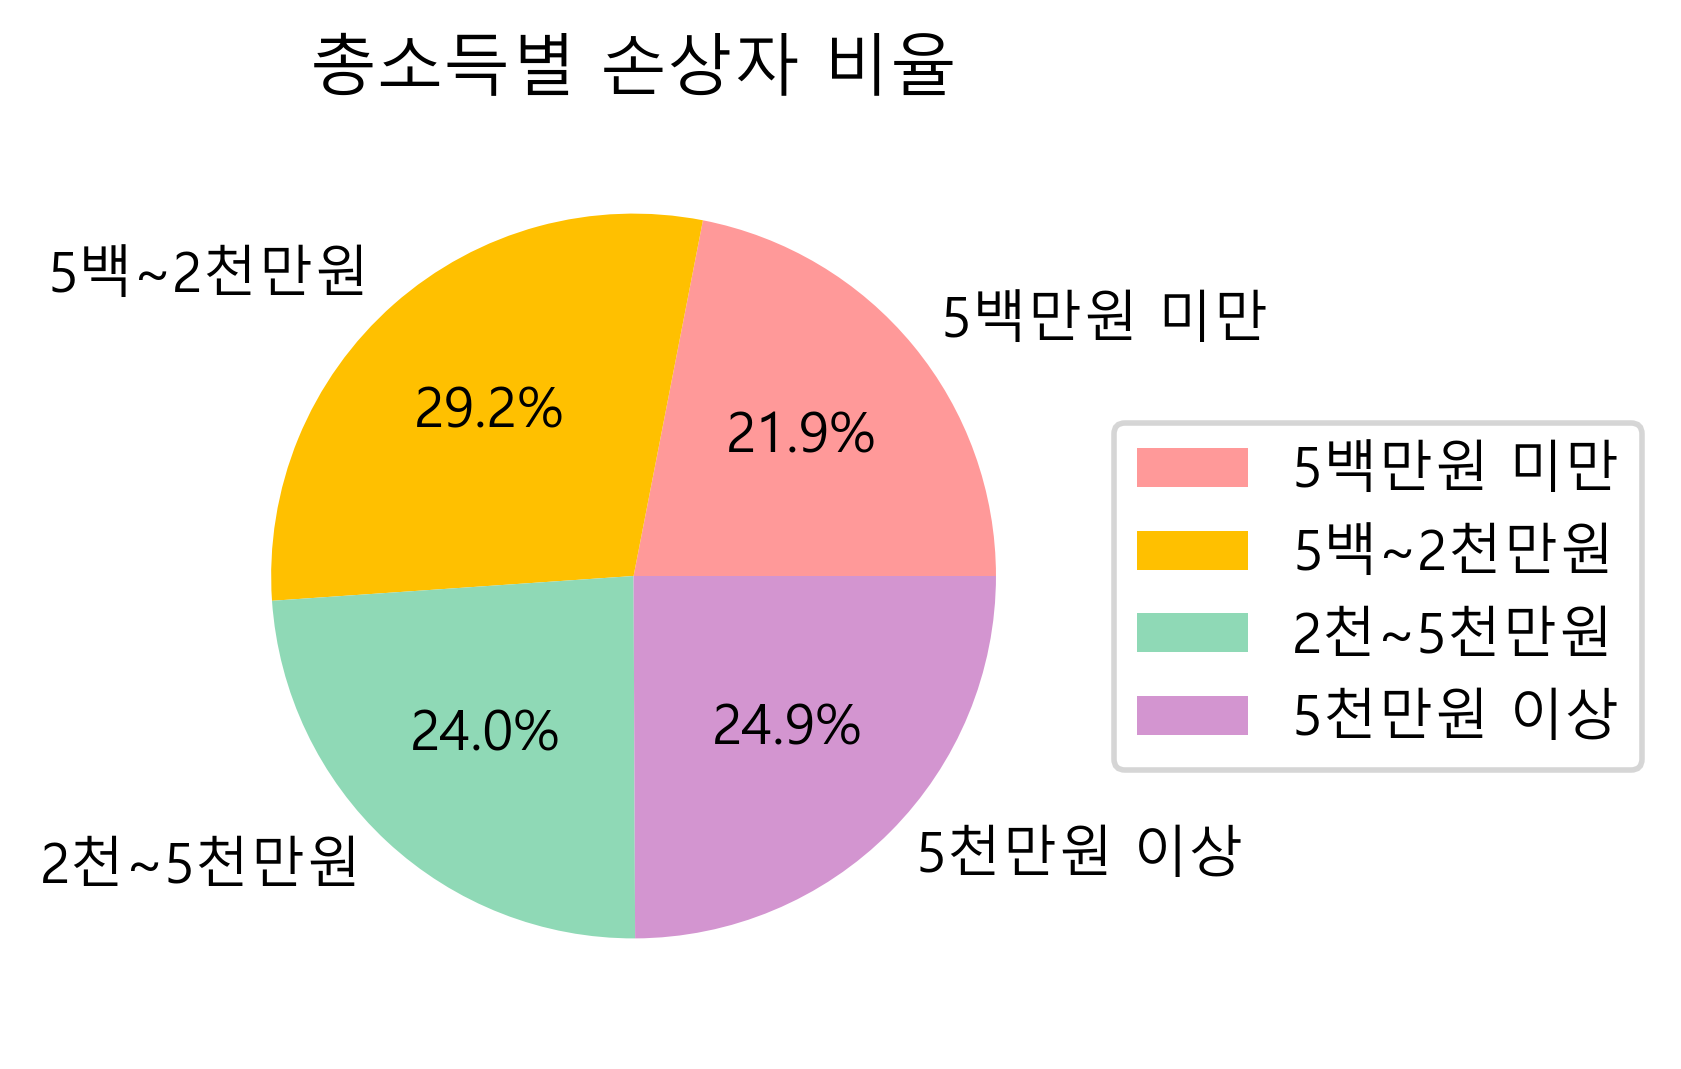

In [31]:
df_in = df_all[['q3', 'target']]

sample_in = pd.DataFrame(columns=['q3','target'])
for i in df_in['q3'].unique():
    temp_in = df_in.query('q3==@i').sample(n=6500, replace = True)
    sample_in = pd.concat([sample_in,temp_in]) 
    
sample_in = sample_in.reset_index(drop=True)

sam_in = pd.pivot_table(sample_in, index = ['q3'], values = 'target', aggfunc = 'sum')

fig = plt.figure(figsize = (3,3), dpi = 200)
ax = fig.subplots()

colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0']
label = ["5백만원 미만", '5백~2천만원', '2천~5천만원', '5천만원 이상']

_ = ax.pie(sam_in['target'], labels = label, colors = colors, autopct = '%1.1f%%')
_ = ax.set_title('총소득별 손상자 비율')
_ = ax.legend(labels = label, bbox_to_anchor = (1.0, 0.7))

### 총소득 중 농업소득 비율

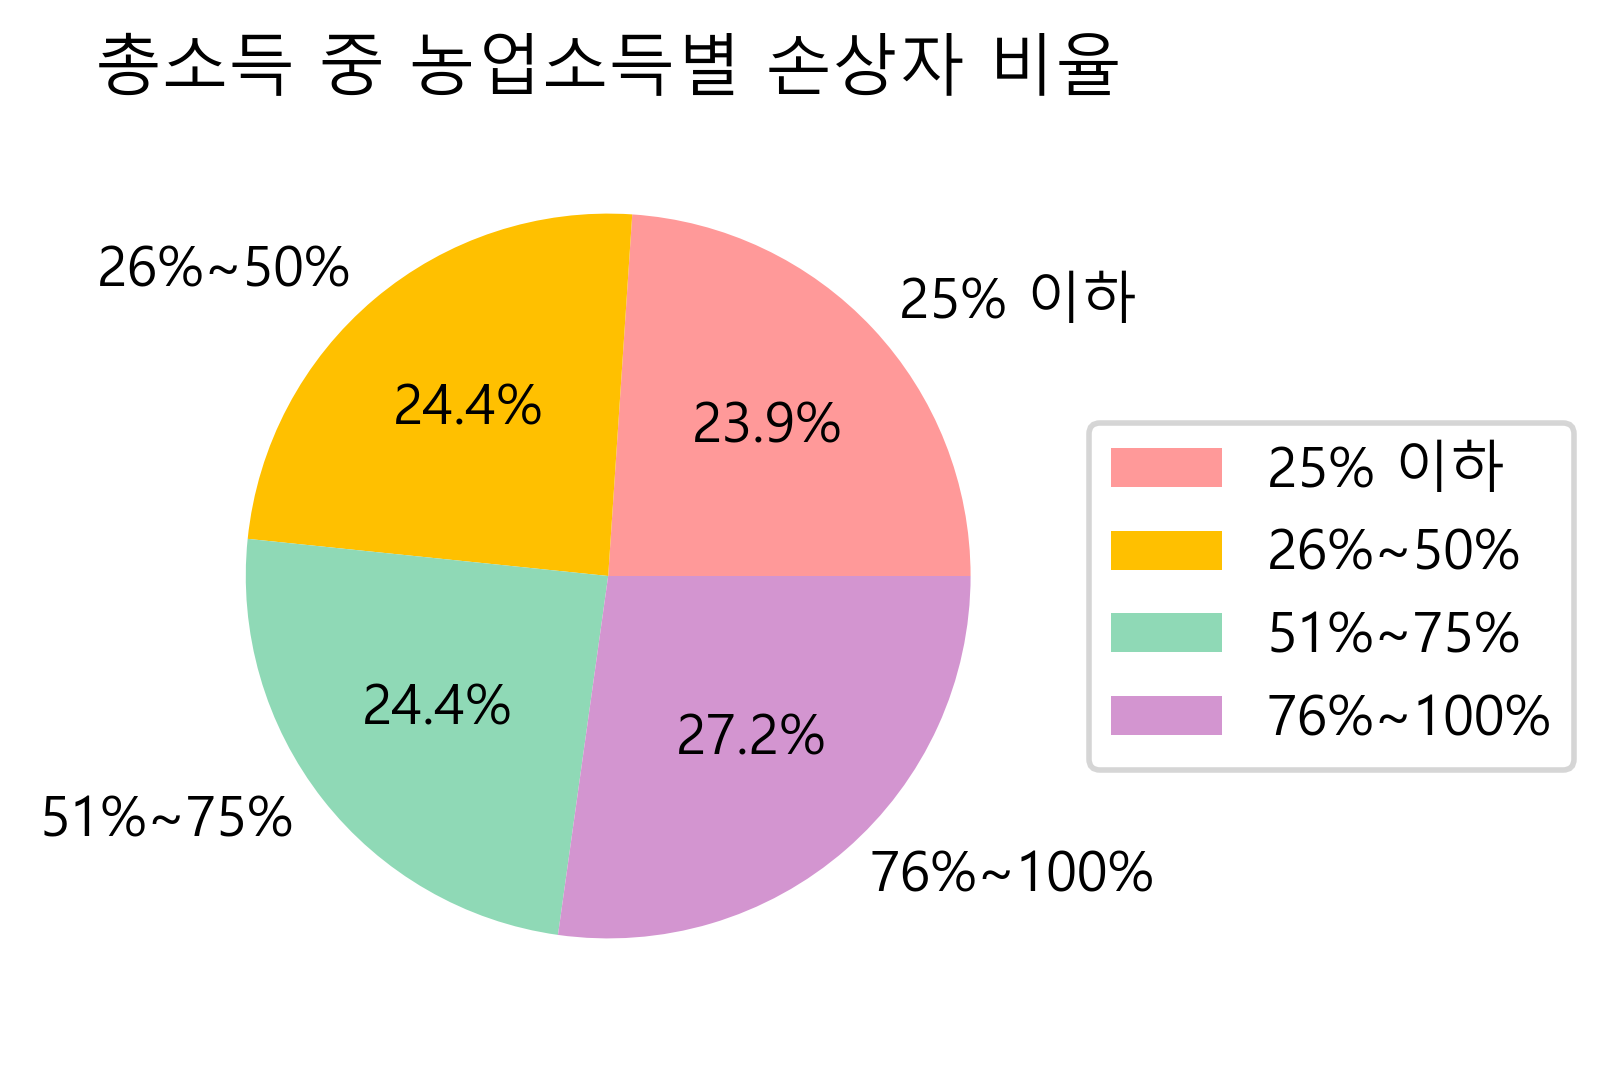

In [32]:
df_in = df_all[['q4', 'target']]
f = pd.pivot_table(df_in, index = ['q4'], values = 'target', aggfunc = 'sum')
sample_in = pd.DataFrame(columns=['q4','target'])
for i in df_in['q4'].unique():
    temp_in = df_in.query('q4==@i').sample(n=9000, replace = True)
    sample_in = pd.concat([sample_in,temp_in]) 
    
sample_in = sample_in.reset_index(drop=True)

sam_in = pd.pivot_table(sample_in, index = ['q4'], values = 'target', aggfunc = 'sum')

fig = plt.figure(figsize = (3,3), dpi = 200)
ax = fig.subplots()

colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0']
label = ["25% 이하", '26%~50%', '51%~75%', '76%~100%']

_ = ax.pie(sam_in['target'], labels = label, colors = colors, autopct = '%1.1f%%')
_ = ax.set_title('총소득 중 농업소득별 손상자 비율')
_ = ax.legend(labels = label, bbox_to_anchor = (1.0, 0.7))

## 상위 3개 지역별 시각화

### 연령

In [33]:
d_all = df_all[df_all['target'] == 1]
d_all.head(2)

,시도명,시군구명,읍면동명,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q7,q14,q17,q31_1,q31_2,q31_3,q31_4,q31_5,q9_남성,q9_여성,...,q27_4,q27_5,q27_6,q27_7,q27_8,q27_9,q27_10,q3,q4,q12,q13,q20,q22,q23,q24,q26,q10,q11,target
54,인천광역시,강화군,불은면,0,1,0,0,0,0,1,0,1,1,1,0,1,1,0,1,...,0,0,0,0,0,0,0,1,4,3,2,2,2,2,1,5,79,59,1
59,인천광역시,강화군,불은면,0,1,0,0,0,0,1,0,0,0,1,0,1,1,1,0,...,1,0,0,0,0,0,0,2,3,3,1,2,1,1,1,5,68,48,1


In [34]:
d_age = d_all[['시도명', 'q10']]

l10 = []
for i in d_age['q10']:
    if i < 50:
        l10.append('20-40대')
    elif 50 <= i < 60:
        l10.append('50대')
    elif 60 <= i < 70:
        l10.append('60대')
    elif 70 <= i < 80:
        l10.append('70대')
    else:
        l10.append('80대 이상')
        
d_age["연령"] = l10
d_age.head(5)

,시도명,q10,연령
54,인천광역시,79,70대
59,인천광역시,68,60대
89,인천광역시,73,70대
117,경기도,62,60대
146,경기도,71,70대


In [35]:
d_age.drop(["q10"], axis = 1, inplace = True)
d_age["count"] = 1
d_age.head(5)

,시도명,연령,count
54,인천광역시,70대,1
59,인천광역시,60대,1
89,인천광역시,70대,1
117,경기도,60대,1
146,경기도,70대,1


In [36]:
d_age = pd.pivot_table(data = d_age, index = ['시도명', '연령'], values = "count", aggfunc = "sum")
d_age = d_age.reset_index()
d_age.head(2)

,시도명,연령,count
0,강원도,20-40대,1
1,강원도,50대,4


<AxesSubplot:xlabel='시도명', ylabel='count'>

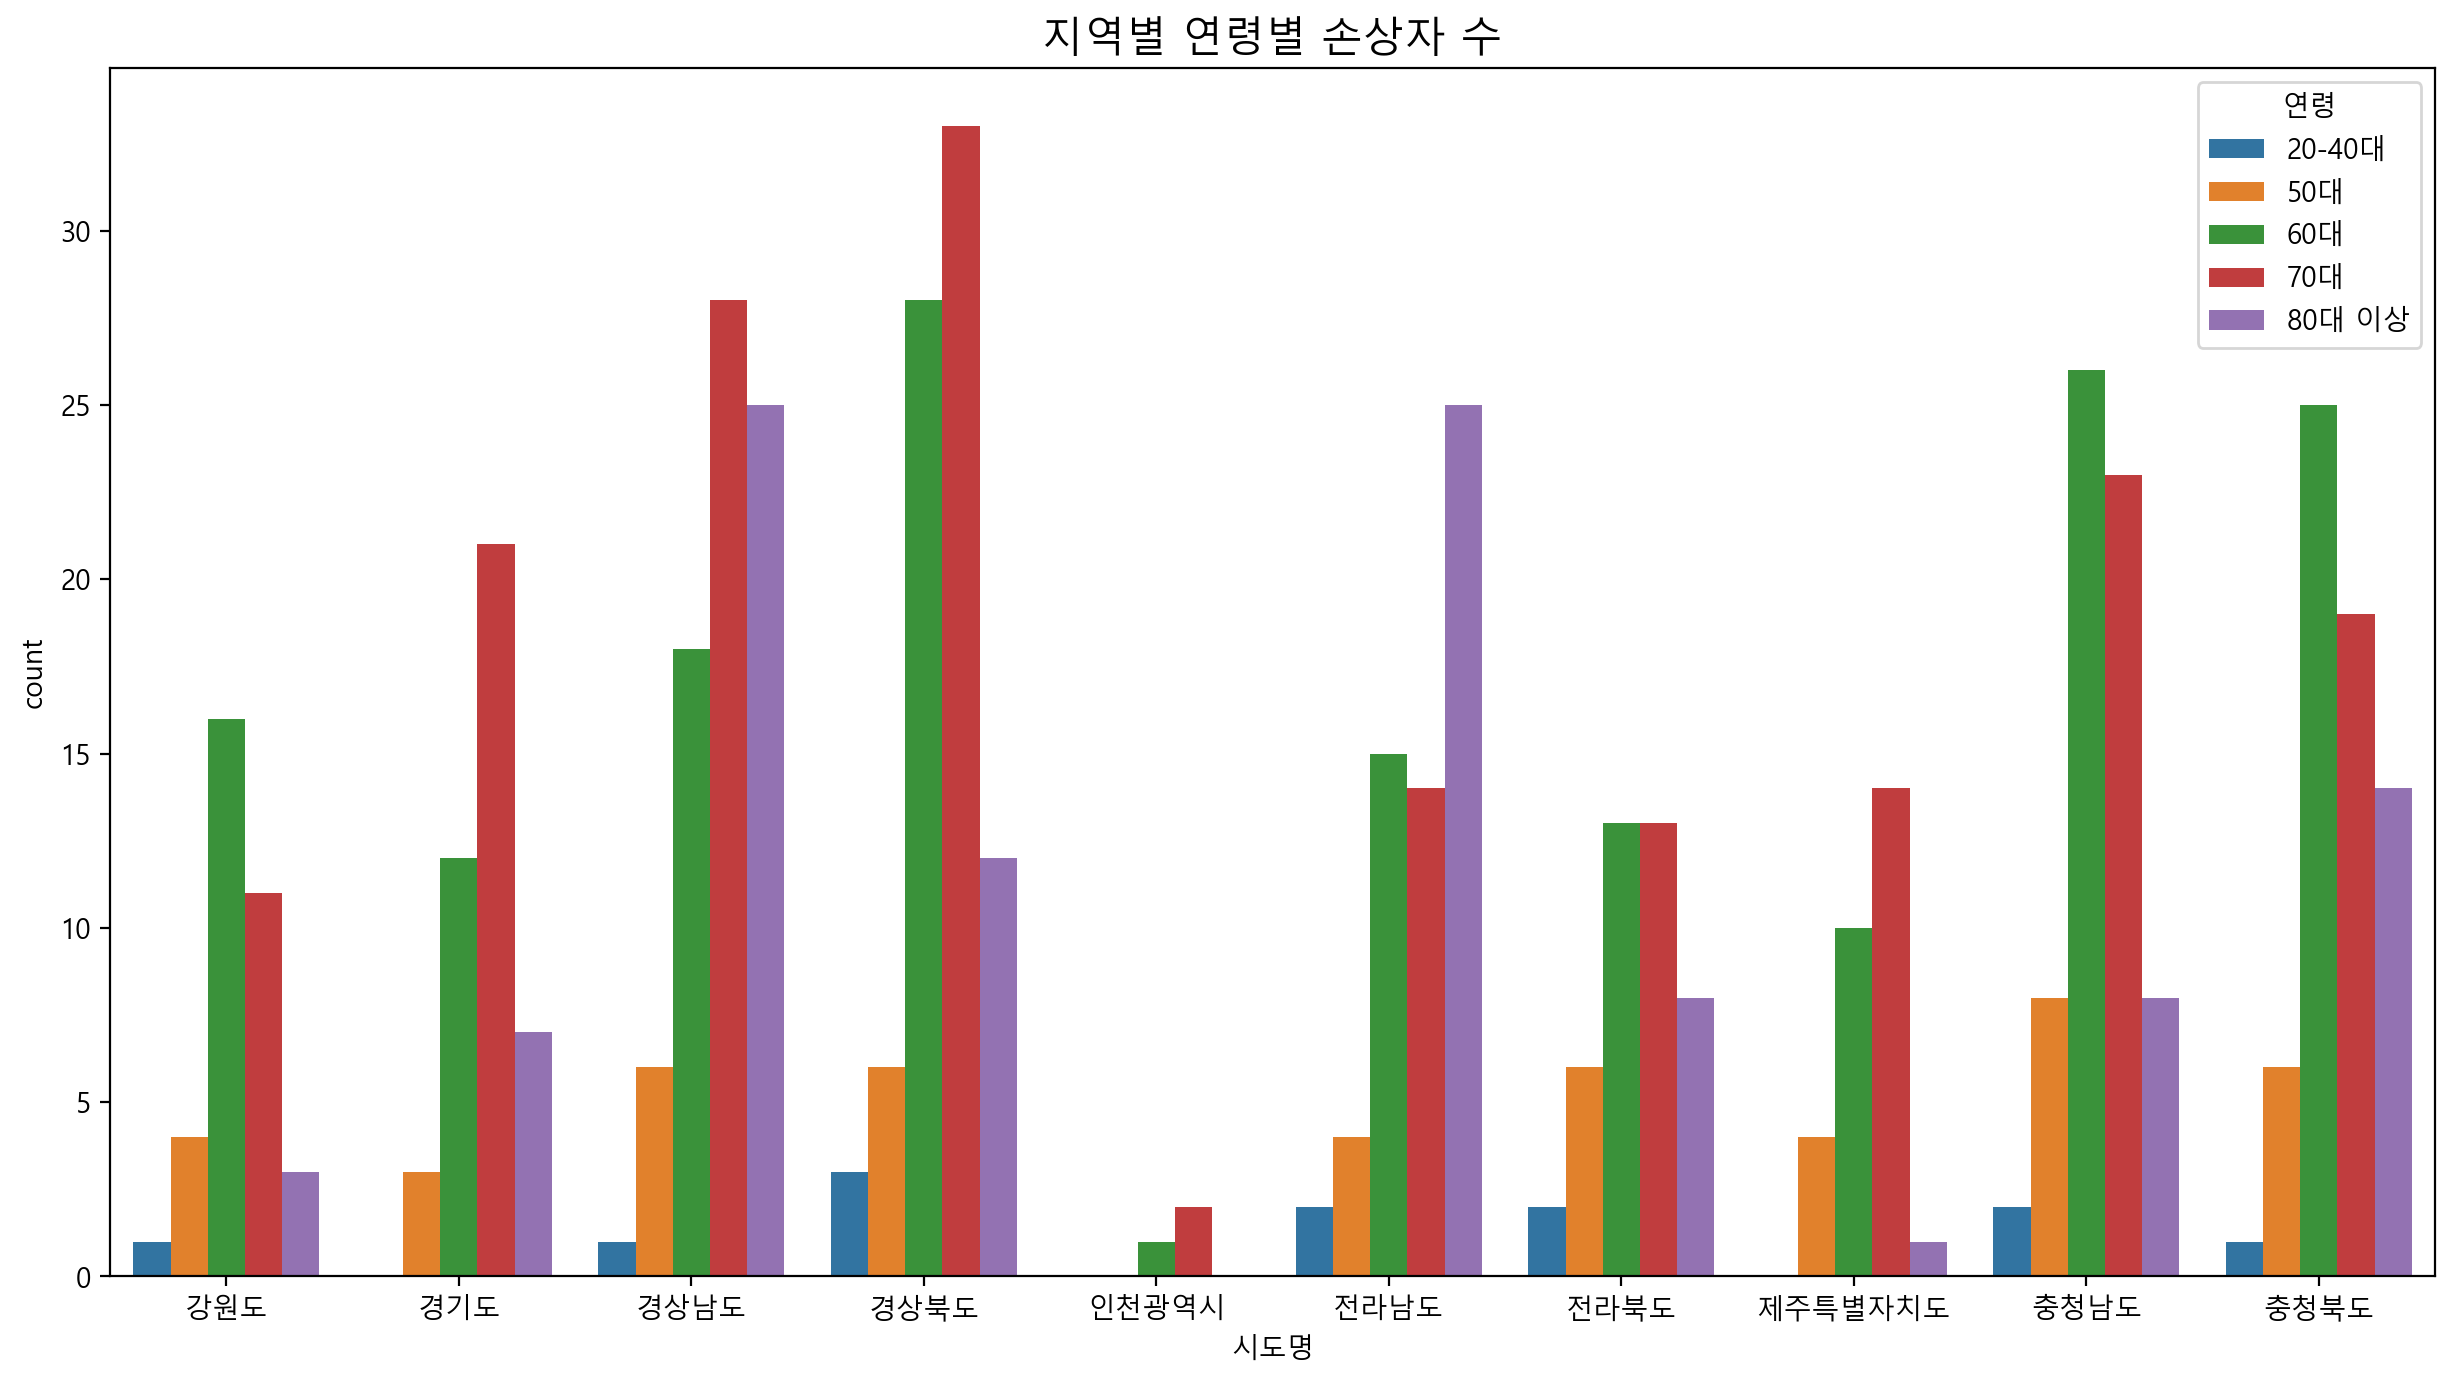

In [37]:
fig = plt.figure(figsize = (15, 8), dpi = 100)
ax = fig.subplots()

sns.barplot(data = d_age, x='시도명', y="count", hue='연령')
_ = ax.set_title('지역별 연령별 손상자 수', fontsize = 15)

### 종사기간

,시도명,종사기간,count
0,강원도,10년 이하,4
1,강원도,약 10~30년,6
2,강원도,약 30년,6
3,강원도,약 40년,8
4,강원도,약 50년,7


<AxesSubplot:xlabel='시도명', ylabel='count'>

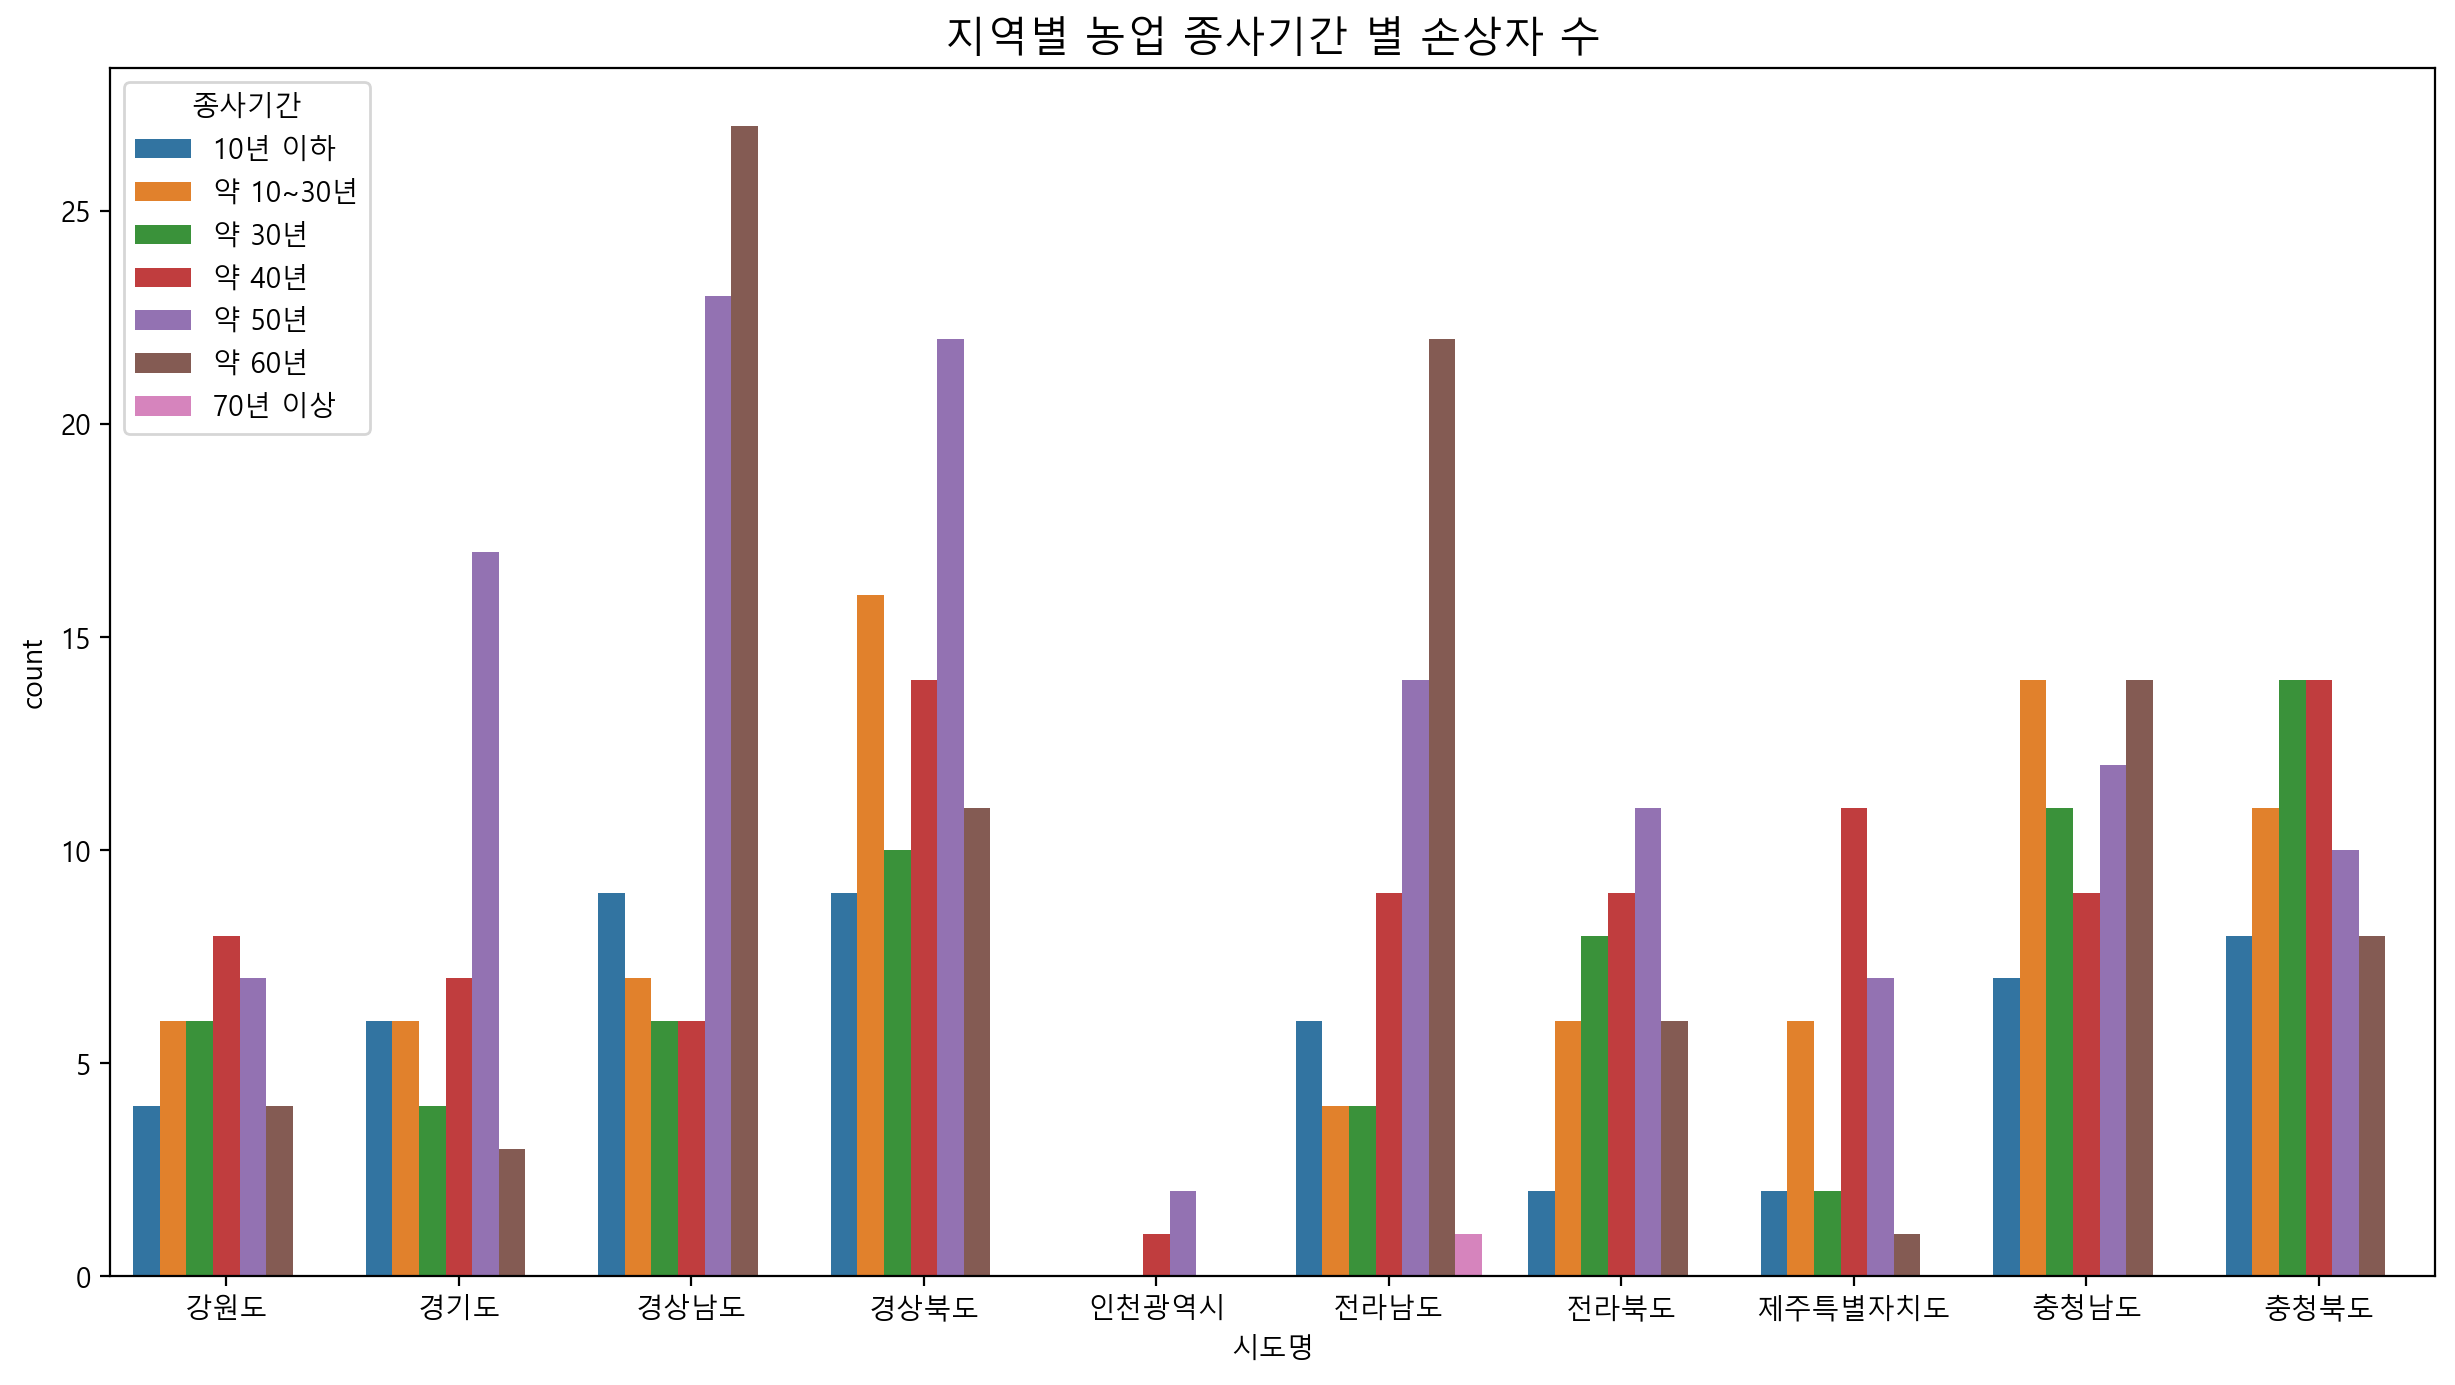

In [38]:
d_y = d_all[['시도명', 'q11']]

l11 = []
for i in d_y['q11']:
    if i > 70:
        l11.append('70년 이상')
    elif 60 <= i < 70:
        l11.append('약 60년')
    elif 50 <= i < 60:
        l11.append('약 50년')
    elif 40 <= i < 50:
        l11.append('약 40년')
    elif 30 <= i < 40:
        l11.append('약 30년')
    elif 10 <= i < 30:
        l11.append('약 10~30년')
    else:
        l11.append('10년 이하')

d_y["종사기간"] = l11

d_year = d_y.drop('q11',axis = 1)

d_year["count"] = 1

d_year = pd.pivot_table(data=d_year, index=['시도명', '종사기간'], values="count", aggfunc="sum")
d_year = d_year.reset_index()
d_year.head()

fig = plt.figure(figsize = (15, 8), dpi = 100)
ax = fig.subplots()

sns.barplot(data = d_year, x = '시도명', y = "count", hue = '종사기간')
_ = ax.set_title('지역별 농업 종사기간 별 손상자 수', fontsize = 15)

### 신체, 정신적 어려움

In [39]:
dt = data[['시도명','q32_1']]
dt = dt.fillna(0).astype({'q32_1':'int'})

li32 = []
for i in dt["q32_1"]:
    if i == 1:
        li32.append('손상')
    else:
        li32.append('비손상')
        
dt["target"]= li32

dt_li = df_all[['시도명','q13']]

li13 = []
for i in dt_li["q13"]:
    if i == 1:
        li13.append('제한X')
    else :
        li13.append('제한O')
        
dt_li["결과"] = li13

dt_li['target'] = dt['target']

d_li = dt_li[dt_li['target'] == '손상']

d_li = pd.pivot_table(data = d_li, index = ["시도명", "결과"], values = "q13", aggfunc = "count")
d_li = d_li.reset_index()
d_li.head()

,시도명,결과,q13
0,강원도,제한O,24
1,강원도,제한X,11
2,경기도,제한O,32
3,경기도,제한X,11
4,경상남도,제한O,71


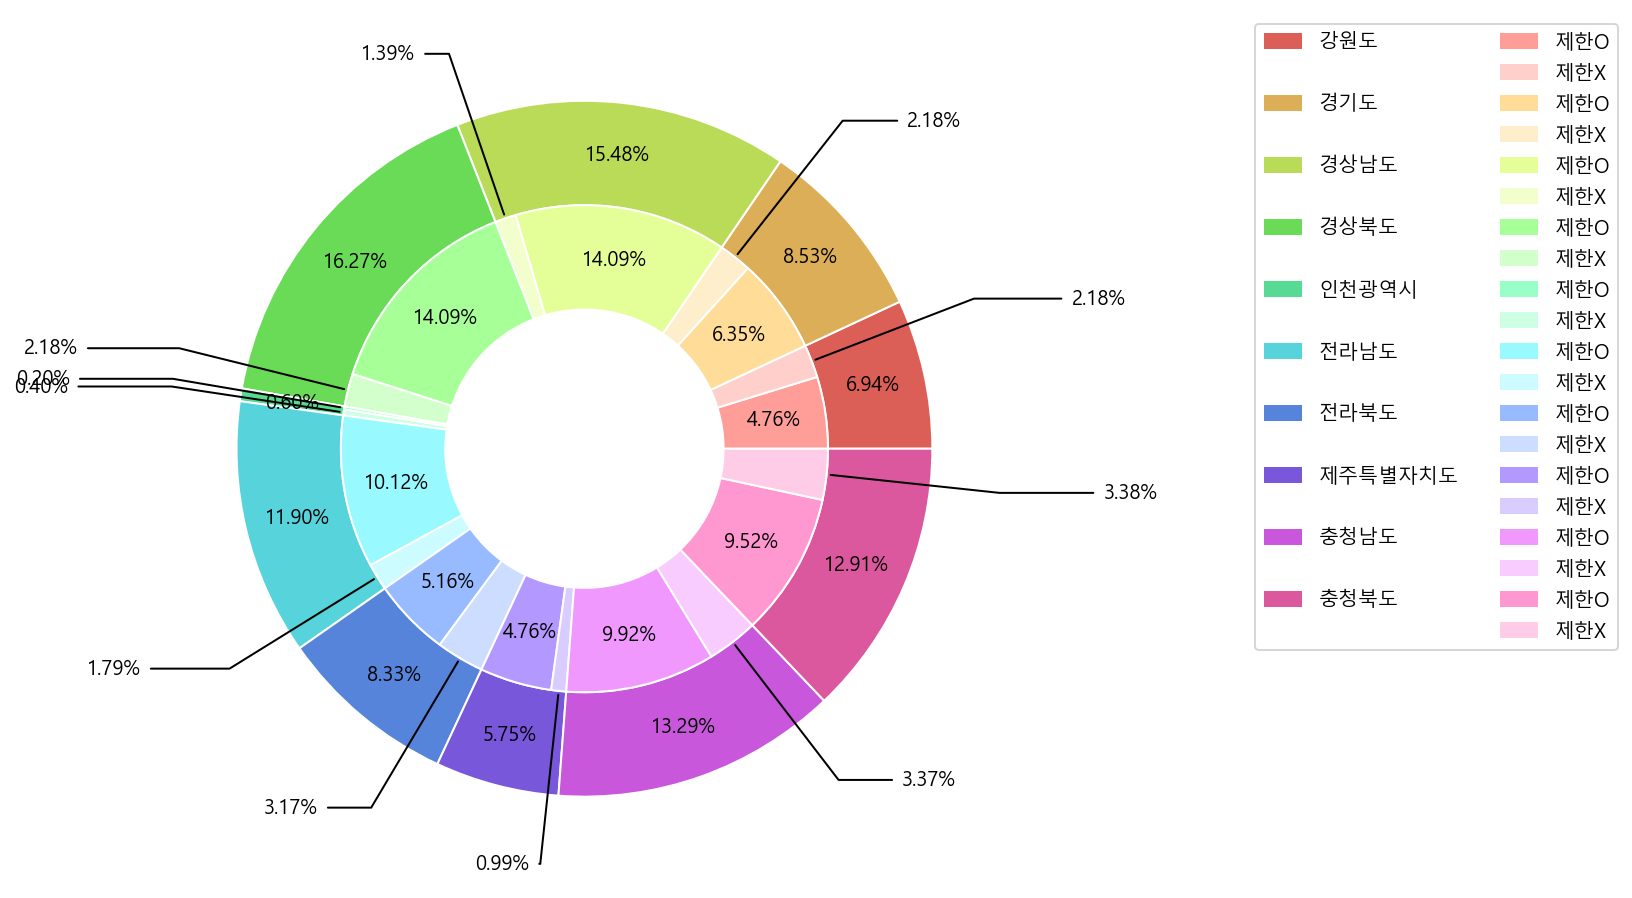

In [44]:
freq_col = 'q13' 
outer_col = '시도명' 
inner_col = '결과' 
 
size = 0.3 
threshold = 4 
 
color = sns.color_palette('hls',len(d_li[outer_col].unique())) 
 
summary = d_li.groupby(outer_col)[freq_col].sum().reset_index() 
outer_data = summary[freq_col] 
inner_data = [] 
for s in summary[outer_col]:
    inner_data += list(d_li.query('{0}==@s'.format(outer_col))[freq_col])

fig = plt.figure(figsize=(8,8)) 
fig.set_facecolor('white') 
_=ax = fig.add_subplot() 
 

out_pie = ax.pie(outer_data,
             radius=1,
             colors=color,
             wedgeprops=dict(width=size,edgecolor='w'))
 
total = np.sum(outer_data) 
 
sum_pct = 0 

for i in range(len(outer_data)):
    ang1, ang2 = out_pie[0][i].theta1, out_pie[0][i].theta2
    out_r = out_pie[0][i].r 
    
    x = ((2*out_r-size)/2)*np.cos(np.pi/180*((ang1+ang2)/2)) 
    y = ((2*out_r-size)/2)*np.sin(np.pi/180*((ang1+ang2)/2)) 
    
    if i < len(outer_data) - 1:
        sum_pct += float(f'{outer_data[i]/total*100:.2f}') 
        _=ax.text(x,y,f'{outer_data[i]/total*100:.2f}%',ha='center',va='center') 
    else: 
        _=ax.text(x,y,f'{100-sum_pct:.2f}%',ha='center',va='center')

outer_color = [] 
for p in out_pie[0]:
    outer_color.append(p.get_facecolor())
outer_color_hsv = [mcl.rgb_to_hsv(x[:3]) for x in outer_color] 
outer_color_hsv = [(x[0],x[1],1) for x in outer_color_hsv] 
 
inner_color = [] 
for i, g in enumerate(summary[outer_col]):
    num_sub_group = len(d_li.query('{0}==@g'.format(outer_col))) 
    jump = outer_color_hsv[i][1]/(num_sub_group+1) 
    temp_list = []
    temp_s = np.arange(0,outer_color_hsv[i][1],jump) 
    temp_s = temp_s[1:] 
    for t in temp_s:
        h = outer_color_hsv[i][0] 
        s = t ## 채도
        v = outer_color_hsv[i][2] 
        temp_list.append((h,s,v))
    inner_color += temp_list[::-1]
    
inner_color = [mcl.hsv_to_rgb(x) for x in inner_color] 
 
inner_pie = ax.pie(inner_data,
       radius=1-size,
       colors=inner_color,
       wedgeprops=dict(width=size,edgecolor='w'))
 
bbox_props = dict(boxstyle='square',fc='w',ec='w',alpha=0) 
config = dict(arrowprops=dict(arrowstyle='-'),bbox=bbox_props,va='center')
 
inner_sum_pct = 0
for i in range(len(inner_data)):
    ang1, ang2 = inner_pie[0][i].theta1, inner_pie[0][i].theta2 
    r = inner_pie[0][i].r 
    
    x = ((2*r-size)/2)*np.cos(np.pi/180*((ang1+ang2)/2)) 
    y = ((2*r-size)/2)*np.sin(np.pi/180*((ang1+ang2)/2)) 
    
    if i < len(inner_data) - 1:
        inner_sum_pct += float(f'{inner_data[i]/total*100:.2f}') 
        text = f'{inner_data[i]/total*100:.2f}%'
    else: 
        text = f'{100-inner_sum_pct:.2f}%'
        
    if inner_data[i]/total*100 < threshold:
        ang = (ang1+ang2)/2 
        x = out_r*np.cos(np.deg2rad(ang))
        y = out_r*np.sin(np.deg2rad(ang)) 
        
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = "angle,angleA=0,angleB={}".format(ang) 
        config["arrowprops"].update({"connectionstyle": connectionstyle}) 
        _=ax.annotate(text, xy=((out_r-size)*x, (out_r-size)*y), xytext=(1.5*x, 1.2*y),
                    horizontalalignment=horizontalalignment, **config)
    else:
        x = ((2*r-size)/2)*np.cos(np.pi/180*((ang1+ang2)/2)) 
        y = ((2*r-size)/2)*np.sin(np.pi/180*((ang1+ang2)/2)) 
        _=ax.text(x,y,text,ha='center',va='center')

inner_pie_index = -1 
right_legend_patches = [] 
left_legend_patches = [] 
right_labels = [] 
left_labels = [] 
for i in range(len(outer_data)):
    left_legend_patches.append(out_pie[0][i])
    
    outer_label = summary[outer_col][i] 
 
    left_labels.append(outer_label)
    temp_data = d_li.query('{0}==@outer_label'.format(outer_col)) 
    temp_data = temp_data.reset_index(drop=True)
    
    temp_number = len(temp_data)-1
    
    for k in range(temp_number):
        rect = mpt.Rectangle((0,0),1,1.1,facecolor='None')
        left_legend_patches.append(rect)
        left_labels.append('')
    
    for j in range(len(temp_data)):
        inner_pie_index += 1
        
        right_legend_patches.append(inner_pie[0][inner_pie_index])
        right_labels.append(temp_data[inner_col][j])
        
    legend_patches = left_legend_patches+right_legend_patches
    labels = left_labels + right_labels
        
plt.legend(legend_patches,
           labels,
           ncol=2,
           loc='upper right',
           handleheight=1, 
           labelspacing=0.5, 
           bbox_to_anchor=(1.7,1))
 
plt.show()

# 특성 중요도에 따른 손상자수 예측

In [49]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from ngboost import NGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import mglearn
import numpy as np

In [50]:
df_sum = pd.pivot_table(df_all, index = ['시군구명'], aggfunc = 'sum')
df_sum = df_sum.reset_index()
df_sum.head()

,시군구명,q10,q11,q12,q13,q14,q17,q20,q22,q23,q24,q26,q27_1,q27_10,q27_2,q27_3,q27_4,q27_5,q27_6,q27_7,q27_8,q27_9,q2_1_1,q2_2_1,q2_3_1,q2_4_1,q2_5_1,q2_6_1,q3,q31_1,q31_2,q31_3,q31_4,q31_5,q4,q7,q9_남성,q9_여성,target
0,가평군,8816,4304,479,175,75,102,324,269,337,254,562,37,8,10,9,18,30,14,16,19,18,30,103,21,3,2,0,274,56,102,62,105,99,422,116,79,47,4
1,강릉시,7166,3989,365,114,55,65,204,147,348,163,499,6,3,8,18,2,30,3,5,1,18,44,100,0,2,4,0,265,54,65,49,82,76,386,96,56,50,1
2,강진군,16904,10635,751,342,112,122,452,360,547,347,1111,86,1,8,5,17,100,5,22,3,17,180,146,2,5,18,0,645,105,140,99,193,179,718,220,99,131,7
3,강화군,6316,3166,296,129,59,51,217,181,189,107,456,23,6,1,0,6,11,7,16,1,5,26,76,1,1,1,0,248,52,74,42,76,74,269,80,50,44,3
4,거제시,17002,10638,864,459,100,145,404,290,250,258,1057,13,0,30,3,5,19,2,14,2,4,94,171,27,5,0,0,446,171,205,175,218,207,630,221,93,137,3


##### 특성 중요도를 독립변수,  target을 종속변수로 설정해 train, test 데이터 생성

In [51]:
d_data = df_sum[['시군구명', 'q10', 'q11', 'q13', 'q3', 'q4', 'q12', 'q23', 'q20', 'q26', 'q22']]
d_target = df_sum["target"]

x_train, x_test, y_train, y_test = train_test_split(d_data,d_target, random_state=0)

X = x_train.iloc[:,1:]
y = y_train
target = x_test.iloc[:,1:]

kf = KFold(n_splits = 50, shuffle = True, random_state = 42)

## GradientBoostingRegressor

In [52]:
gbm = GradientBoostingRegressor(random_state = 42)

rmse_list = []
gb_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in kf.split(X, y) : 
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    gbm.fit(tr_x, tr_y) 
   
    pred = [0 if x < 0 else x for x in gbm.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in gbm.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))  
    
    rmse_list.append(rmse)
    
    gb_pred += (sub_pred / 50)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

...

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

GradientBoostingRegressor(random_state=42)

In [53]:
np.mean(rmse_list)

3.304177573110961

## RandomForestRegressor

In [54]:
rf = RandomForestRegressor(random_state = 518)

rmse_list = []
rf_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in kf.split(X, y) :
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    rf.fit(tr_x, tr_y)
    
    pred = [0 if x < 0 else x for x in rf.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in rf.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))
    
    rmse_list.append(rmse)
    
    rf_pred += (sub_pred / 50)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

...

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

RandomForestRegressor(random_state=518)

In [55]:
np.mean(rmse_list)

2.824328331836489

## NGBRegressor

In [56]:
from tqdm import tqdm

In [58]:
ngb = NGBRegressor(random_state = 518)

rmse_list = []
ngb_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in tqdm(kf.split(X, y)) :
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    ngb.fit(tr_x, tr_y)
    
    pred = [0 if x < 0 else x for x in ngb.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in ngb.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))
    
    rmse_list.append(rmse)
    
    ngb_pred += (sub_pred / 50)

0it [00:00, ?it/s]

[iter 0] loss=2.8766 val_loss=0.0000 scale=1.0000 norm=3.3865
[iter 100] loss=2.1248 val_loss=0.0000 scale=2.0000 norm=3.1901
[iter 200] loss=1.4819 val_loss=0.0000 scale=2.0000 norm=1.8992
[iter 300] loss=1.0358 val_loss=0.0000 scale=1.0000 norm=0.7266
[iter 400] loss=0.6574 val_loss=0.0000 scale=1.0000 norm=0.5895


NGBRegressor(random_state=RandomState(MT19937) at 0x245E3688240)

1it [00:05,  5.12s/it]

[iter 0] loss=1.0699 val_loss=0.0000 scale=1.0000 norm=1.2368
[iter 100] loss=0.1275 val_loss=0.0000 scale=1.0000 norm=0.4656
[iter 200] loss=-0.1067 val_loss=0.0000 scale=1.0000 norm=0.3978
[iter 300] loss=-0.3409 val_loss=0.0000 scale=1.0000 norm=0.3611
[iter 400] loss=-0.5777 val_loss=0.0000 scale=1.0000 norm=0.3268


...

NGBRegressor(random_state=RandomState(MT19937) at 0x245E3688240)

49it [06:14, 11.12s/it]

[iter 0] loss=829649908.0484 val_loss=0.0000 scale=0.0000 norm=395.6079
[iter 100] loss=-2.4028 val_loss=0.0000 scale=2.0000 norm=0.7340
[iter 200] loss=-3.4193 val_loss=0.0000 scale=2.0000 norm=0.9722
[iter 300] loss=-4.8397 val_loss=0.0000 scale=4.0000 norm=1.9971
[iter 400] loss=-7.2597 val_loss=0.0000 scale=8.0000 norm=4.0000


NGBRegressor(random_state=RandomState(MT19937) at 0x245E3688240)

50it [06:25,  7.71s/it]


In [59]:
np.mean(rmse_list)

0.08451977902515556

## XGBRegressor

In [60]:
xgb = XGBRegressor(random_state = 518)

rmse_list = []
xgb_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in kf.split(X, y) :
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    xgb.fit(tr_x, tr_y)
    
    pred = [0 if x < 0 else x for x in xgb.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in xgb.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))
    
    rmse_list.append(rmse)
    
    xgb_pred += (sub_pred / 50)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

...

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=6,
             num_parallel_tree=1, predictor='auto', random_state=518,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [61]:
np.mean(rmse_list)

3.1607332671371635

## CatBoostRegressor

In [62]:
cat = CatBoostRegressor(random_state = 518, silent = True)

rmse_list = []
cat_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in kf.split(X, y) :
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    cat.fit(tr_x, tr_y)
    
    pred = [0 if x < 0 else x for x in cat.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in cat.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))
    
    rmse_list.append(rmse)
    
    cat_pred += (sub_pred / 50)

In [63]:
np.mean(rmse_list)

3.0408275636408546

## LGBMRegressor

In [64]:
lgbm = LGBMRegressor(random_state = 518)

rmse_list = []
lgb_pred = np.zeros((x_test.shape[0]))
for tr_idx, val_idx in kf.split(X, y) :
    tr_x, tr_y = X.iloc[tr_idx], y.iloc[tr_idx]
    val_x, val_y = X.iloc[val_idx], y.iloc[val_idx]
    
    lgbm.fit(tr_x, tr_y)
    
    pred = [0 if x < 0 else x for x in lgbm.predict(val_x)]
    pred = np.array(pred)
    sub_pred = [0 if x < 0 else x for x in lgbm.predict(target)]
    sub_pred = np.array(sub_pred)
    rmse = np.sqrt(mean_squared_error(val_y, pred))
    
    rmse_list.append(rmse)
    
    lgb_pred += (sub_pred / 50)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

...

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

LGBMRegressor(random_state=518)

In [65]:
np.mean(rmse_list)

2.974704952562714

## 예측 결과를 포함한 x_test 데이터 생성

In [66]:
x_test['target'] = ngb_pred
x_test_pred = x_test.sort_values(by = 'target', ascending = False)
x_test_pred.head(5)

,시군구명,q10,q11,q13,q3,q4,q12,q23,q20,q26,q22,target
24,남해군,25063,13452,488,790,1034,1321,567,796,1739,577,13.008338
7,경주시,26818,13895,549,678,1257,1320,1008,781,1713,555,12.717809
43,아산시,22937,14022,614,651,1086,1143,1264,819,1580,435,12.358888
8,고성군,20320,11820,440,542,770,1034,411,638,1333,411,11.686056
22,나주시,23429,15074,472,961,1039,1092,706,654,1499,575,10.112956


# 예측 결과 확인

## 연령

In [67]:
gyeong=df_all[df_all['시군구명']=='경주시']
gyeong=gyeong[['q10','target']]

gyeong2=gyeong[['q10','target']]
d = []
for i in gyeong["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
gyeong2["target"]= d

gyeong3=gyeong2[['q10','target']]
q = []
for i in gyeong2['q10']:
    if i < 50:
        q.append('20-40대')
    elif 50 <= i < 60:
        q.append('50대')
    elif 60 <= i < 70:
        q.append('60대')
    elif 70 <= i < 80:
        q.append('70대')
    else:
        q.append('80대 이상')

gyeong3["연령"]= q

gyeong4=gyeong3[gyeong3['target']=='손상']

ex2=pd.DataFrame({'target':['손상', '손상'],
                             '연령':['20-40대','80대 이상'],
                             'q10':[0,0]})

Gyeong = pd.pivot_table(data=gyeong4, index=["target","연령"], values="q10", aggfunc="count")
Gyeong=Gyeong.reset_index()
Gyeong=Gyeong.append(ex2)
Gyeong=Gyeong.sort_values('연령')

In [68]:
nam=df_all[df_all['시군구명']=='남해군']
nam=nam[['q10','target']]

nam2=nam[['q10','target']]
d = []
for i in nam["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
nam2["target"]= d

nam3=nam2[['q10','target']]
q = []
for i in nam2['q10']:
    if i < 50:
        q.append('20-40대')
    elif 50 <= i < 60:
        q.append('50대')
    elif 60 <= i < 70:
        q.append('60대')
    elif 70 <= i < 80:
        q.append('70대')
    else:
        q.append('80대 이상')

nam3["연령"]= q

nam4=nam3[nam3['target']=='손상']

ex2=pd.DataFrame({'target':['손상', '손상'],
                             '연령':['20-40대','50대'],
                             'q10':[0,0]})

Nam = pd.pivot_table(data=nam4, index=["target","연령"], values="q10", aggfunc="count")
Nam=Nam.reset_index()
Nam=Nam.append(ex2)
Nam=Nam.sort_values('연령')

In [69]:
go=df_all[df_all['시군구명']=='고성군']
go=go[['q10','target']]

go2=go[['q10','target']]
d = []
for i in go["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
go2["target"]= d

go3=go2[['q10','target']]
q = []
for i in go2['q10']:
    if i < 50:
        q.append('20-40대')
    elif 50 <= i < 60:
        q.append('50대')
    elif 60 <= i < 70:
        q.append('60대')
    elif 70 <= i < 80:
        q.append('70대')
    else:
        q.append('80대 이상')

go3["연령"]= q

go4=go3[go3['target']=='손상']

ex2=pd.DataFrame({'target':['손상'],
                             '연령':['20-40대'],
                             'q10':[0]})

Go = pd.pivot_table(data=go4, index=["target","연령"], values="q10", aggfunc="count")
Go=Go.reset_index()
Go=Go.append(ex2)
Go=Go.sort_values('연령')

In [70]:
asan=df_all[df_all['시군구명']=='아산시']
asan=asan[['q10','target']]

asan2=asan[['q10','target']]
d = []
for i in asan["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
asan2["target"]= d

asan3=asan2[['q10','target']]
q = []
for i in asan2['q10']:
    if i < 50:
        q.append('20-40대')
    elif 50 <= i < 60:
        q.append('50대')
    elif 60 <= i < 70:
        q.append('60대')
    elif 70 <= i < 80:
        q.append('70대')
    else:
        q.append('80대 이상')

asan3["연령"]= q

asan4=asan3[asan3['target']=='손상']

ex2=pd.DataFrame({'target':['손상','손상'],
                             '연령':['20-40대','50대'],
                             'q10':[0,0]})

Asan = pd.pivot_table(data=asan4, index=["target","연령"], values="q10", aggfunc="count")
Asan=Asan.reset_index()
Asan=Asan.append(ex2)
Asan=Asan.sort_values('연령')

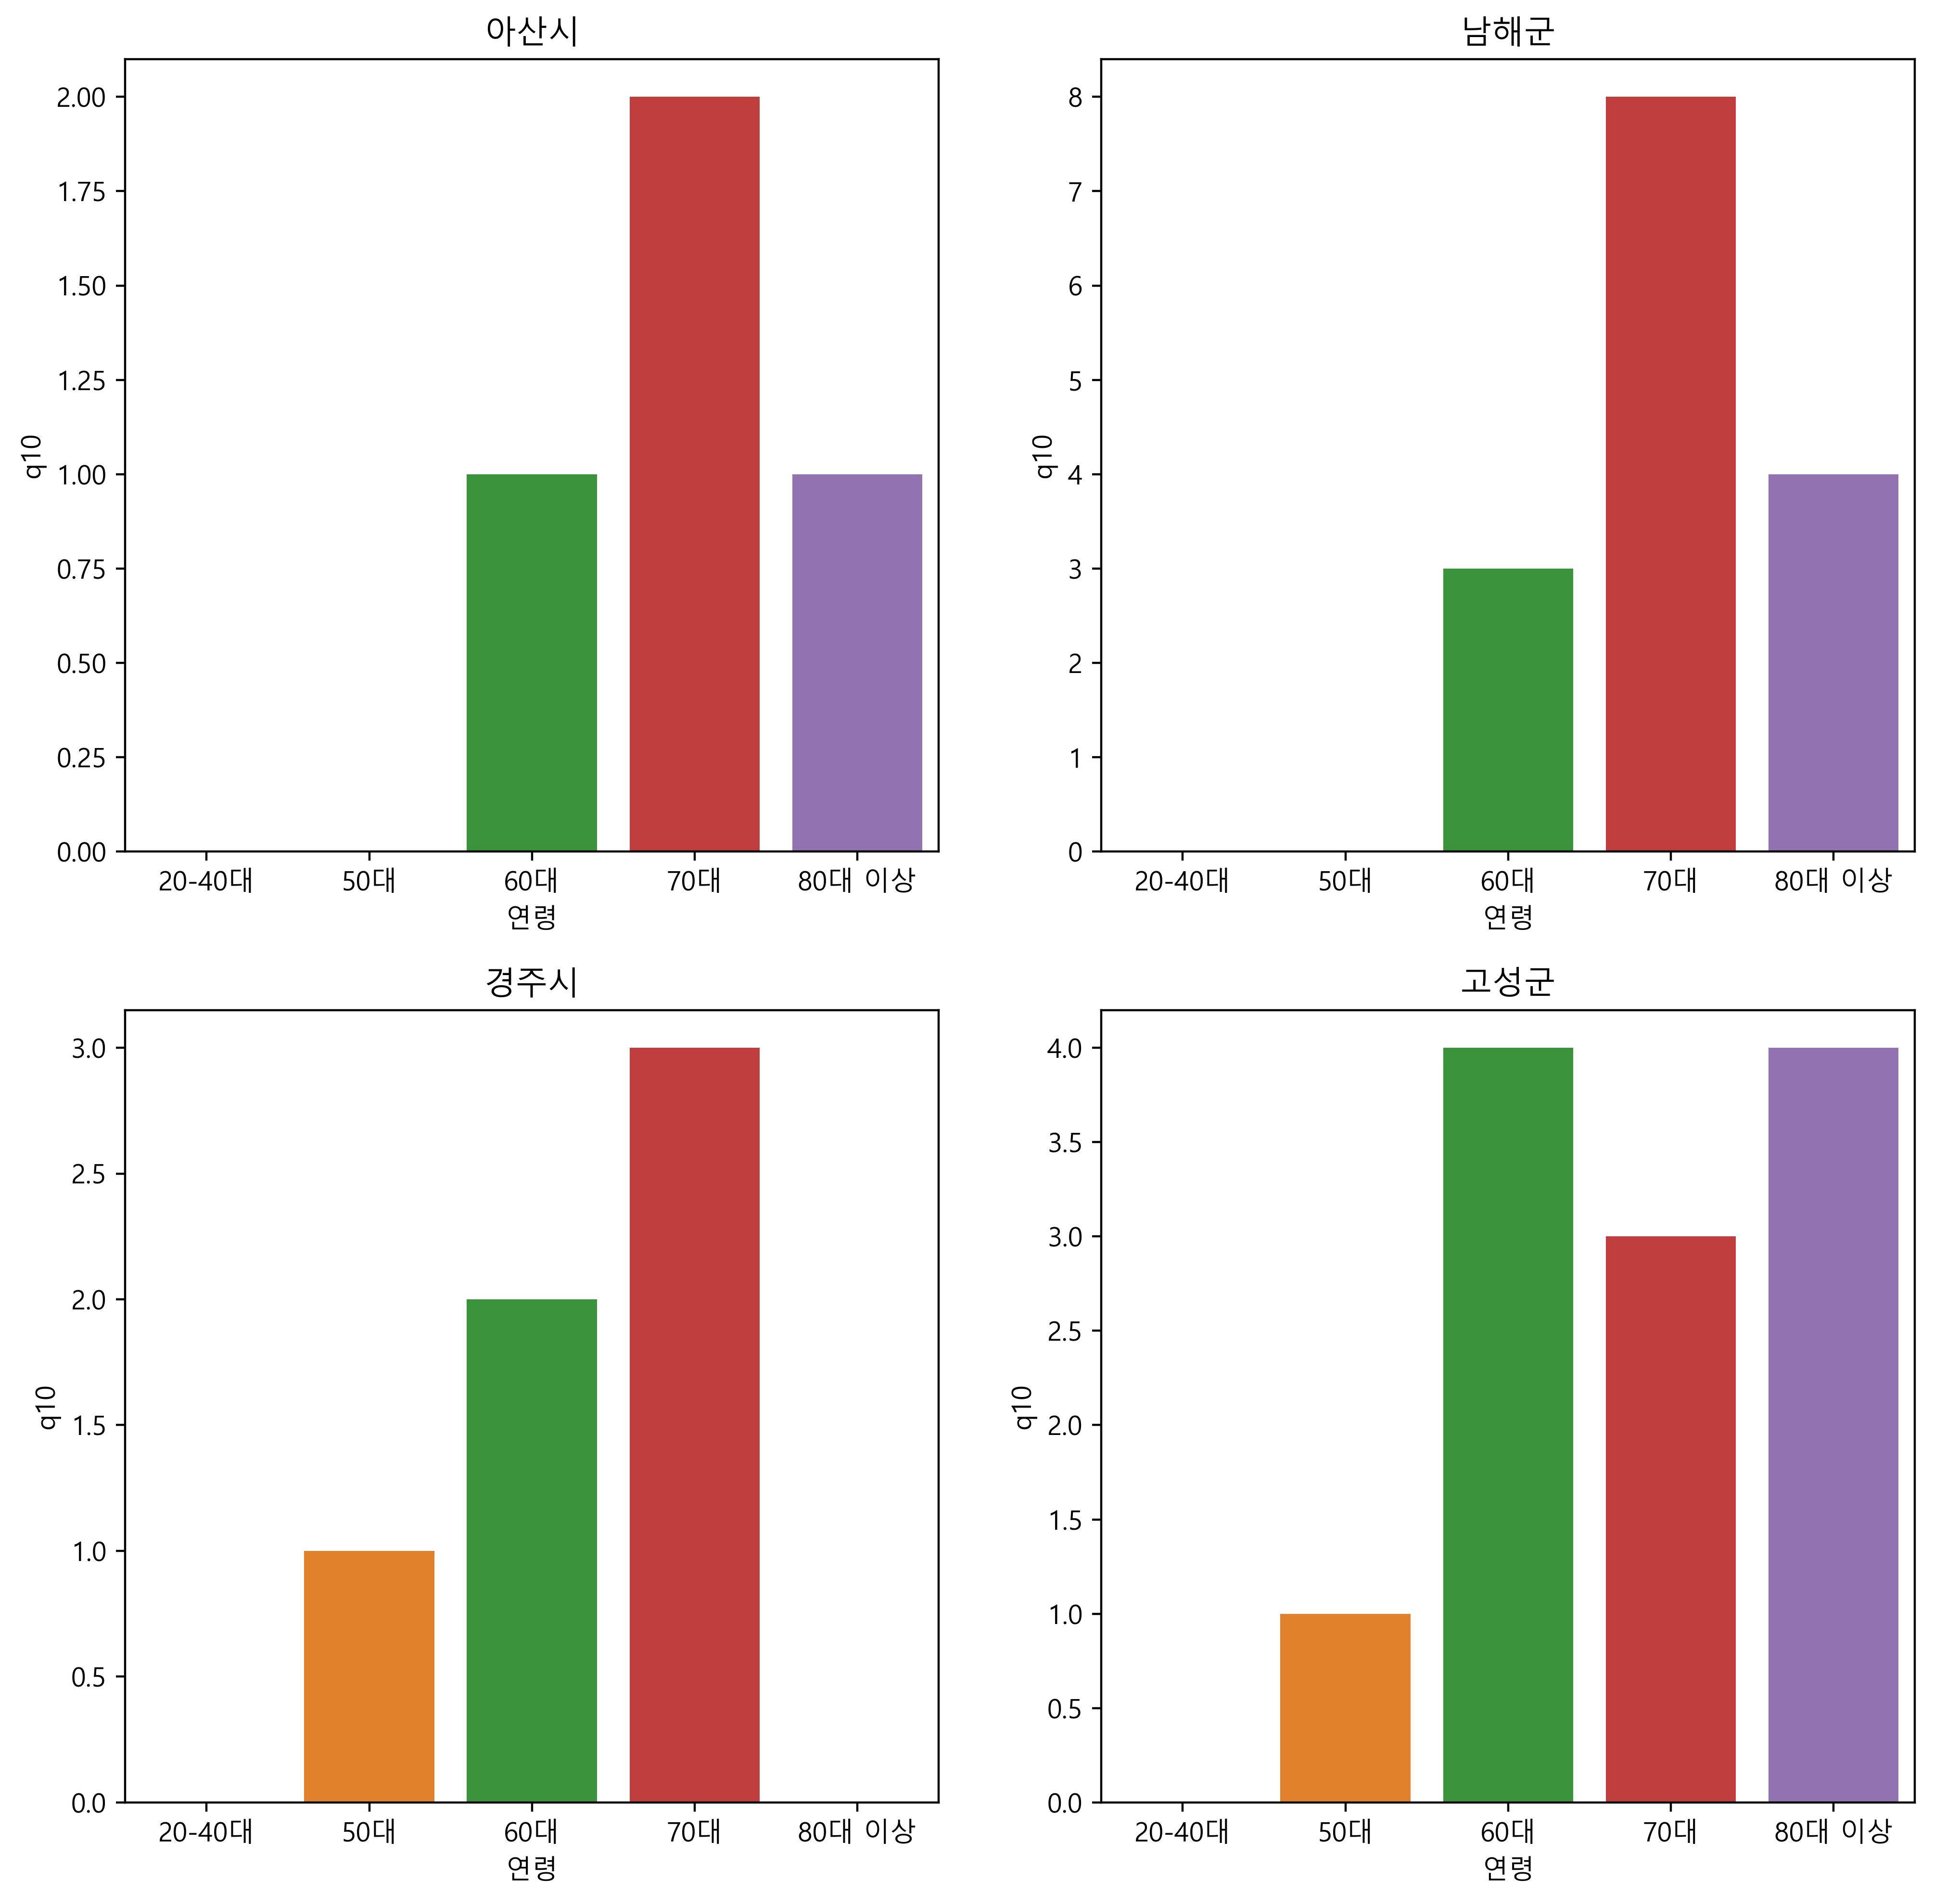

In [71]:
fig=plt.figure(figsize=(12,12), dpi=200)
axs=fig.subplots(2,2).flatten()

_=sns.barplot(data=Asan,x='연령', y='q10' ,ax=axs[0])
_=sns.barplot(data=Nam,x='연령', y='q10' ,ax=axs[1])
_=sns.barplot(data=Gyeong,x='연령', y='q10' ,ax=axs[2])
_=sns.barplot(data=Go,x='연령', y='q10' ,ax=axs[3])

_=axs[0].set_title("아산시")
_=axs[1].set_title("남해군")
_=axs[2].set_title("경주시")
_=axs[3].set_title("고성군")

## 종사기간

In [72]:
gyeong=df_all[df_all['시군구명']=='경주시']
gyeong=gyeong[['q11','target']]

gyeong2=gyeong[['q11','target']]
d = []
for i in gyeong["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
gyeong2["target"]= d

gyeong3=gyeong2[['q11','target']]

q1 = []
for i in gyeong2['q11']:
    if i >= 60:
        q1.append('60년 이상')
    elif 50 <= i < 60:
        q1.append('약 50년')
    elif 40 <= i < 50:
        q1.append('약 40년')
    elif 30 <= i < 40:
        q1.append('약 30년')
    elif 10 <= i < 30:
        q1.append('약 10~30년')
    else:
        q1.append('10년 이하')
gyeong3["종사기간"]= q1

gyeong4=gyeong3[gyeong3['target']=='손상']

ex2=pd.DataFrame({'target':['손상', '손상'],
                             '종사기간':['10년 이하', '60년 이상'],
                             'q11':[0,0]})

Gyeong = pd.pivot_table(data=gyeong4, index=["target","종사기간"], values="q11", aggfunc="count")
Gyeong=Gyeong.reset_index()
Gyeong=Gyeong.append(ex2)
Gyeong=Gyeong.sort_values('종사기간')

In [73]:
asan=df_all[df_all['시군구명']=='아산시']
asan=asan[['q11','target']]

asan2=asan[['q11','target']]
d = []
for i in asan["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
asan2["target"]= d

asan3=asan2[['q11','target']]

q1 = []
for i in asan2['q11']:
    if i >= 60:
        q1.append('60년 이상')
    elif 50 <= i < 60:
        q1.append('약 50년')
    elif 40 <= i < 50:
        q1.append('약 40년')
    elif 30 <= i < 40:
        q1.append('약 30년')
    elif 10 <= i < 30:
        q1.append('약 10~30년')
    else:
        q1.append('10년 이하')
asan3["종사기간"]= q1

asan4=asan3[asan3['target']=='손상']

ex2=pd.DataFrame({'target':['손상', '손상', '손상', '손상'],
                             '종사기간':['10년 이하', '약 10~30년','약 30년','약 50년'],
                             'q11':[0,0,0,0]})

Asan = pd.pivot_table(data=asan4, index=["target","종사기간"], values="q11", aggfunc="count")
Asan=Asan.reset_index()
Asan=Asan.append(ex2)
Asan=Asan.sort_values('종사기간')

In [74]:
nam=df_all[df_all['시군구명']=='남해군']
nam=nam[['q11','target']]

nam2=nam[['q11','target']]
d = []
for i in nam["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
nam2["target"]= d

nam3=nam2[['q11','target']]
q1 = []
for i in nam2['q11']:
    if i >= 60:
        q1.append('60년 이상')
    elif 50 <= i < 60:
        q1.append('약 50년')
    elif 40 <= i < 50:
        q1.append('약 40년')
    elif 30 <= i < 40:
        q1.append('약 30년')
    elif 10 <= i < 30:
        q1.append('약 10~30년')
    else:
        q1.append('10년 이하')
nam3["종사기간"]= q1

nam4=nam3[nam3['target']=='손상']

Nam = pd.pivot_table(data=nam4, index=["target","종사기간"], values="q11", aggfunc="count")
Nam=Nam.reset_index()
Nam=Nam.sort_values('종사기간')

In [75]:
go=df_all[df_all['시군구명']=='고성군']
go=go[['q11','target']]

go2=go[['q11','target']]
d = []
for i in go["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
go2["target"]= d

go3=go2[['q11','target']]
q1 = []
for i in go2['q11']:
    if i >= 60:
        q1.append('60년 이상')
    elif 50 <= i < 60:
        q1.append('약 50년')
    elif 40 <= i < 50:
        q1.append('약 40년')
    elif 30 <= i < 40:
        q1.append('약 30년')
    elif 10 <= i < 30:
        q1.append('약 10~30년')
    else:
        q1.append('10년 이하')
go3["종사기간"]= q1

go4=go3[go3['target']=='손상']

ex2=pd.DataFrame({'target':['손상'],
                             '종사기간':['10년 이하'],
                             'q11':[0]})
Go = pd.pivot_table(data=go4, index=["target","종사기간"], values="q11", aggfunc="count")
Go=Go.reset_index()
Go=Go.append(ex2)
Go=Go.sort_values('종사기간')

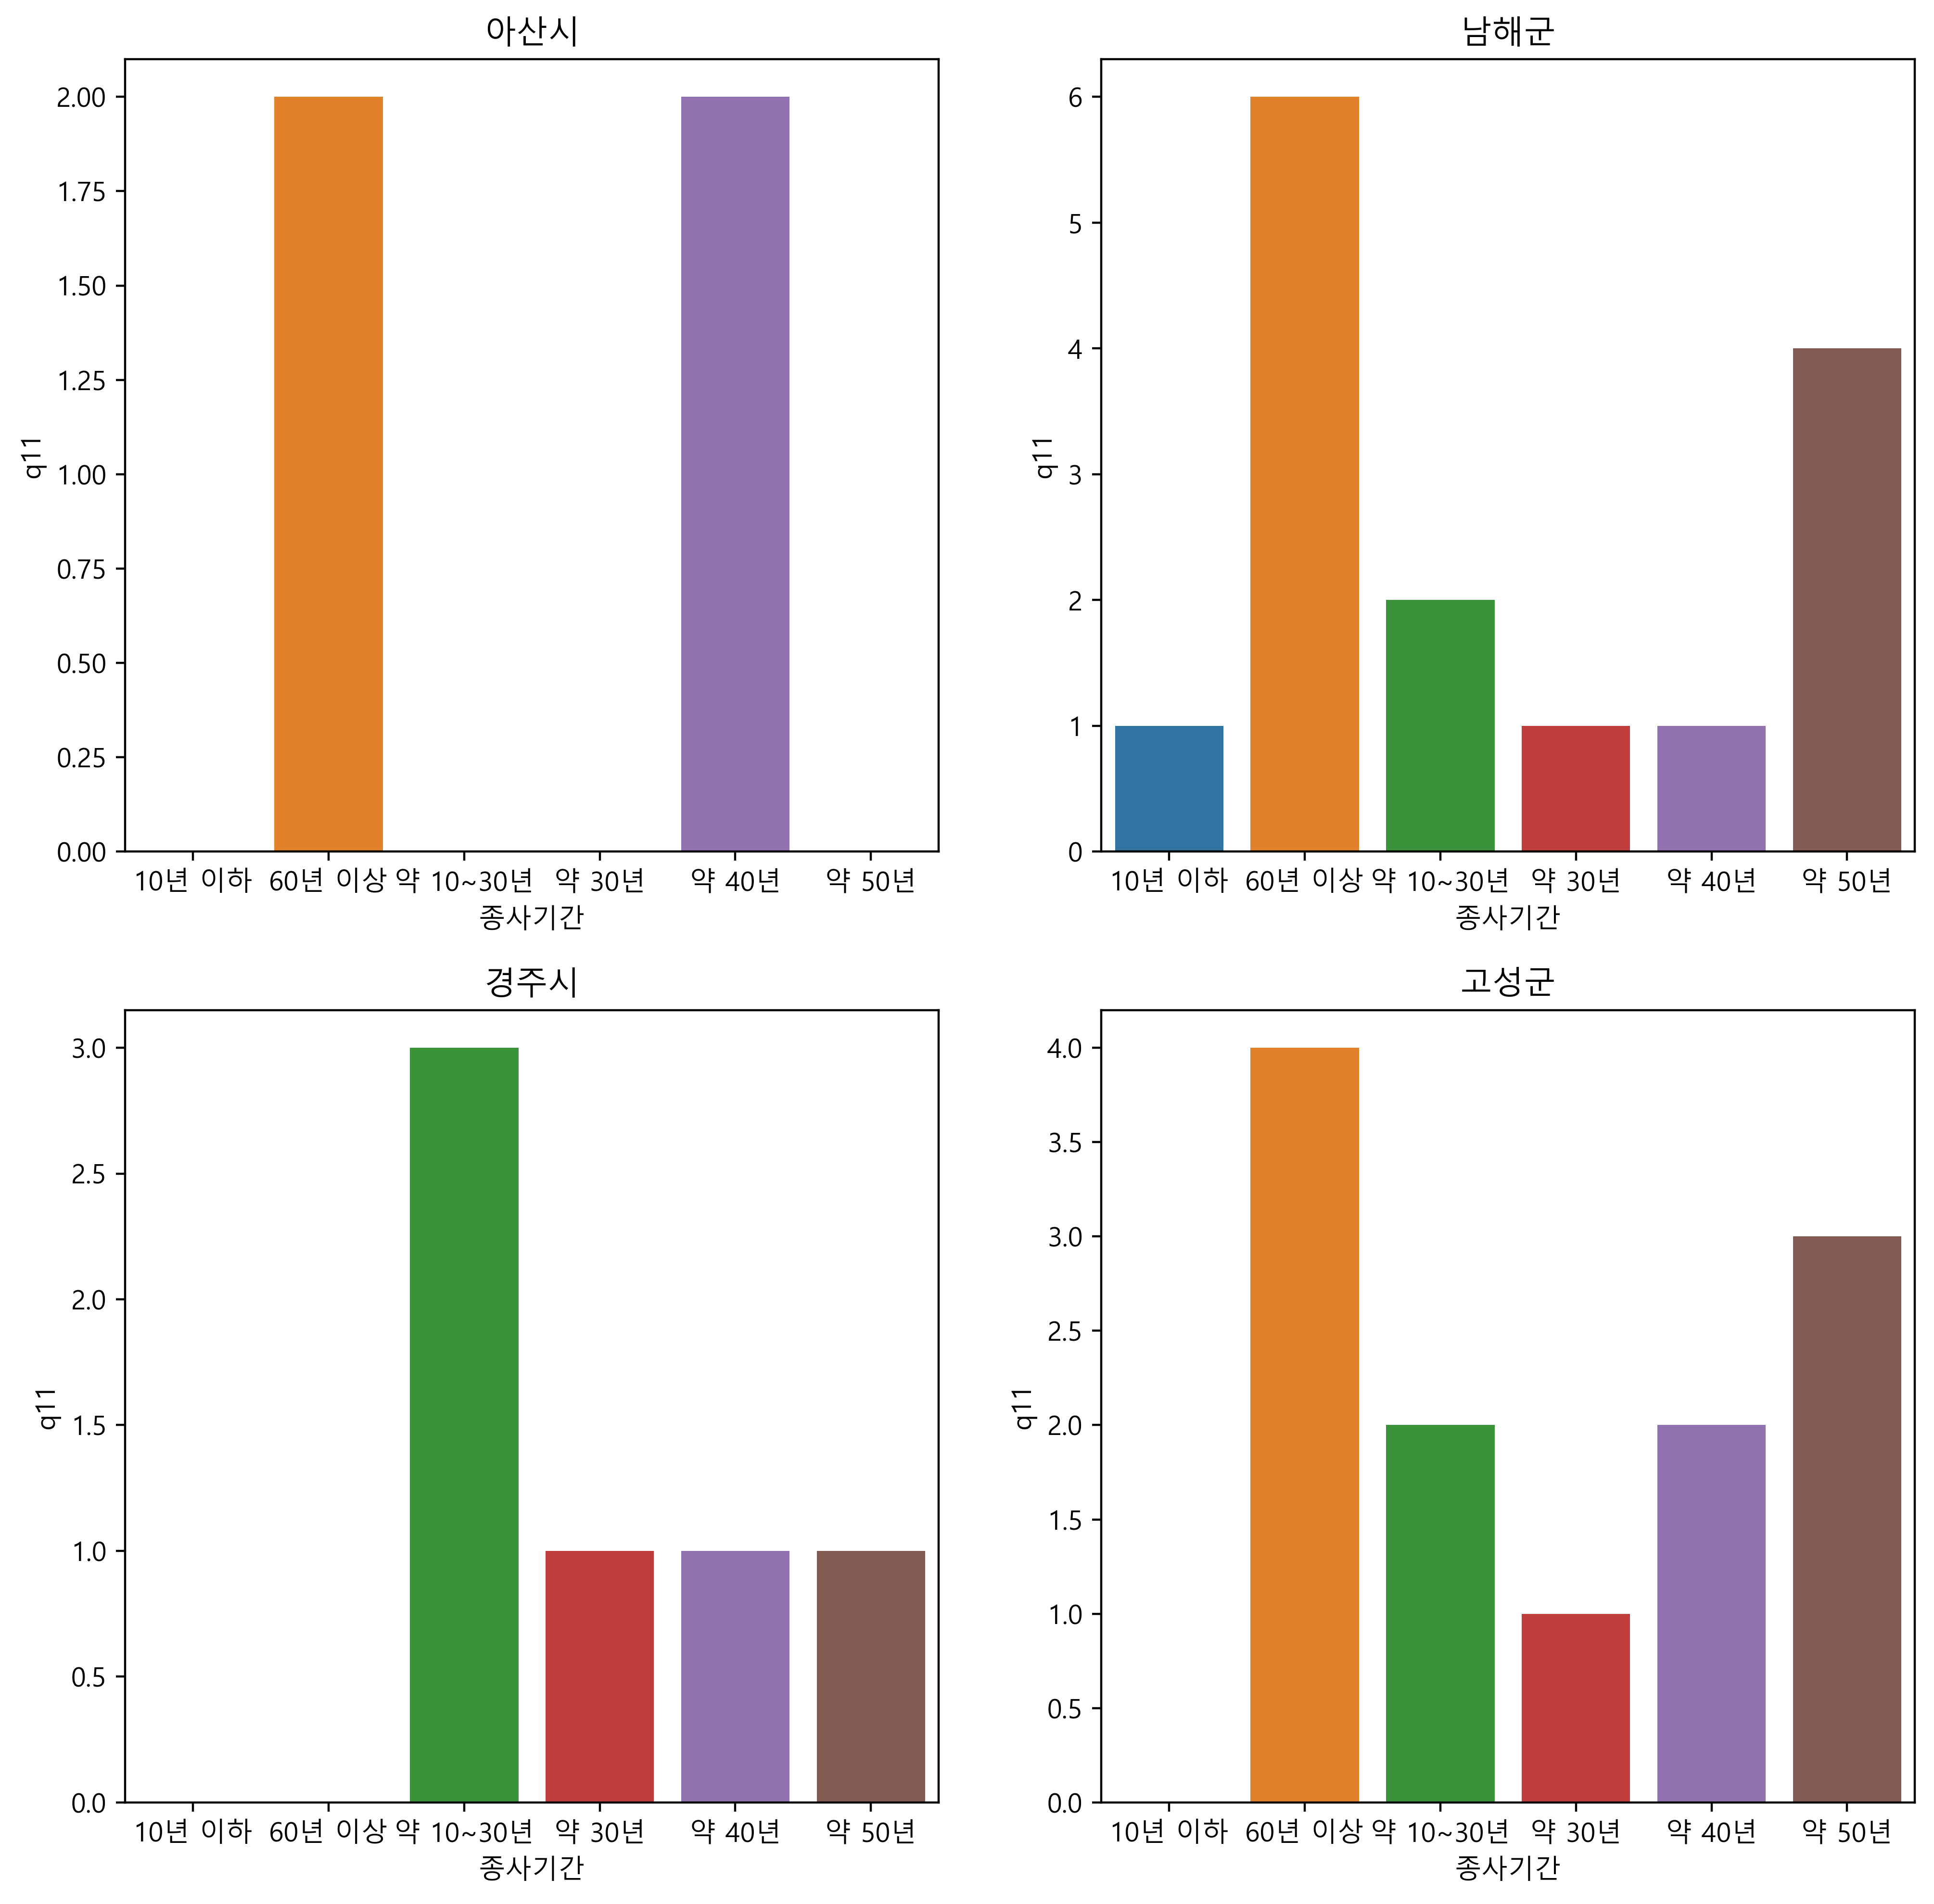

In [76]:
fig=plt.figure(figsize=(12,12), dpi=200)
axs=fig.subplots(2,2).flatten()
colors=['#ff9999','#ffc000', '#8fd9b6','#d395d0','#dfd4e4', '#83a7a3', '#acb890']

_=sns.barplot(data=Asan,x='종사기간', y='q11' ,ax=axs[0])
_=sns.barplot(data=Nam,x='종사기간', y='q11' ,ax=axs[1])
_=sns.barplot(data=Gyeong,x='종사기간', y='q11' ,ax=axs[2])
_=sns.barplot(data=Go,x='종사기간', y='q11' ,ax=axs[3])

_=axs[0].set_title("아산시")
_=axs[1].set_title("남해군")
_=axs[2].set_title("경주시")
_=axs[3].set_title("고성군")

## 신체, 정신적 어려움

In [77]:
gyeong=df_all[df_all['시군구명']=='경주시']
gyeong=gyeong[['q13','target']]

gyeong2=gyeong[['q13','target']]
d = []
for i in gyeong["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
gyeong2["target"]= d

gyeong3=gyeong2[['q13','target']]
d = []
for i in gyeong2["q13"]:
    if i == 1:
        d.append('제한X')
    else :
        d.append('제한O')
        
gyeong3["결과"]= d

gyeong4=gyeong3[gyeong3['target']=='손상']

Gyeong = pd.pivot_table(data=gyeong4, index=["target","결과"], values="q13", aggfunc="count")
Gyeong=Gyeong.reset_index()
Gyeong.loc[len(Gyeong)]=['손상','제한X',0]
Gyeong=Gyeong.sort_values('결과')

In [78]:
asan=df_all[df_all['시군구명']=='아산시']
asan=asan[['q13','target']]

asan2=asan[['q13','target']]
d = []
for i in asan["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
asan2["target"]= d

asan3=asan2[['q13','target']]
d = []
for i in asan2["q13"]:
    if i == 1:
        d.append('제한X')
    else :
        d.append('제한O')
        
asan3["결과"]= d

asan4=asan3[asan3['target']=='손상']

Asan = pd.pivot_table(data=asan4, index=["target","결과"], values="q13", aggfunc="count")
Asan=Asan.reset_index()
Asan.loc[len(Asan)]=['손상','제한X',0]
Asan=Asan.sort_values('결과')

In [79]:
nam=df_all[df_all['시군구명']=='남해군']
nam=nam[['q13','target']]

nam2=nam[['q13','target']]
d = []
for i in nam["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
nam2["target"]= d

nam3=nam2[['q13','target']]
d = []
for i in nam2["q13"]:
    if i == 1:
        d.append('제한X')
    else :
        d.append('제한O')
        
nam3["결과"]= d

nam4=nam3[nam3['target']=='손상']

Nam = pd.pivot_table(data=nam4, index=["target","결과"], values="q13", aggfunc="count")
Nam=Nam.reset_index()
Nam=Nam.sort_values('결과')

In [80]:
go=df_all[df_all['시군구명']=='고성군']
go=go[['q13','target']]

go2=go[['q13','target']]
d = []
for i in go["target"]:
    if i == 1:
        d.append('손상')
    else:
        d.append('비손상')
        
go2["target"]= d

go3=go2[['q13','target']]
d = []
for i in go2["q13"]:
    if i == 1:
        d.append('제한X')
    else :
        d.append('제한O')
        
go3["결과"]= d

go4=go3[go3['target']=='손상']

Go = pd.pivot_table(data=go4, index=["target","결과"], values="q13", aggfunc="count")
Go=Go.reset_index()
Go=Go.sort_values('결과')

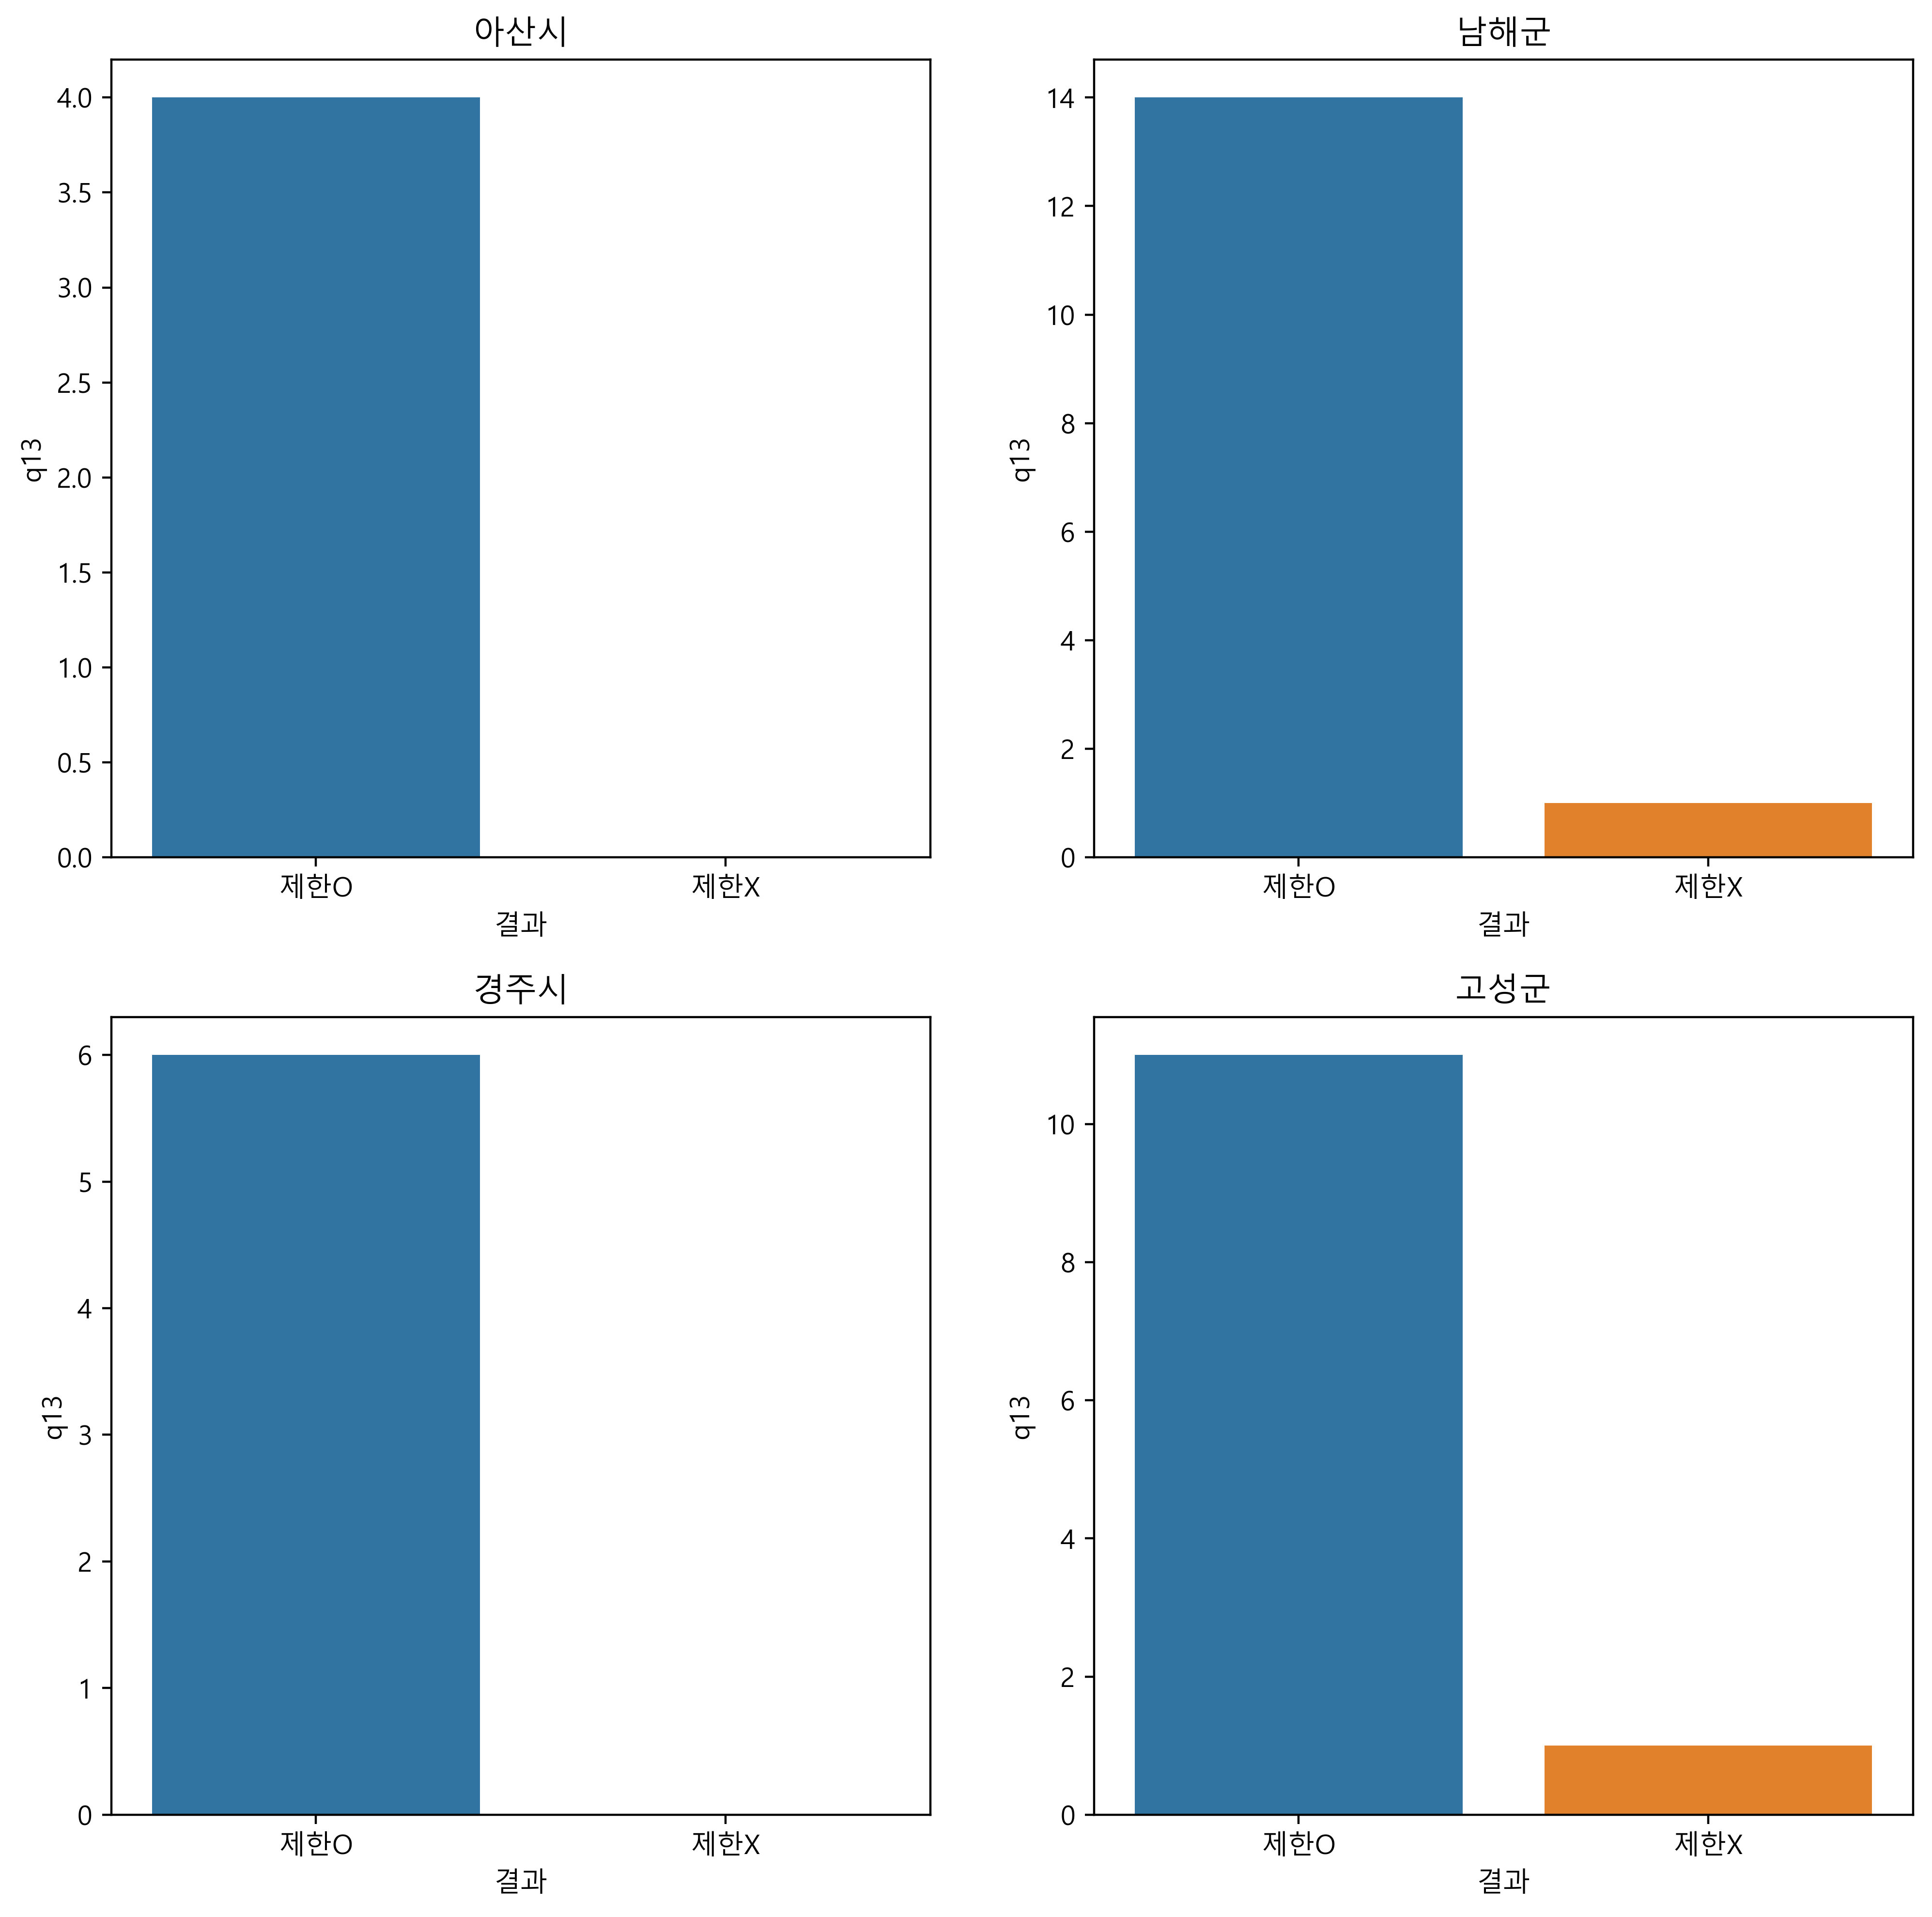

In [81]:
fig=plt.figure(figsize=(12,12), dpi=200)
axs=fig.subplots(2,2).flatten()
colors=['#ff9999','#ffc000', '#8fd9b6','#d395d0','#dfd4e4', '#83a7a3', '#acb890']

_=sns.barplot(data=Asan,x='결과', y='q13' ,ax=axs[0])
_=sns.barplot(data=Nam,x='결과', y='q13' ,ax=axs[1])
_=sns.barplot(data=Gyeong,x='결과', y='q13' ,ax=axs[2])
_=sns.barplot(data=Go,x='결과', y='q13' ,ax=axs[3])

_=axs[0].set_title("아산시")
_=axs[1].set_title("남해군")
_=axs[2].set_title("경주시")
_=axs[3].set_title("고성군")